## 1 - Install Packages

In [1]:
# ============================================================
# Cell 1: Install packages (Colab-safe)
# ============================================================
!pip -q install --upgrade pip
!pip -q install "jax[cpu]" optax pandas matplotlib scikit-learn networkx torch torchvision torchaudio
!pip -q install torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.7 MB/s eta 0:00:00


## 2 - imports and configs

In [2]:
# ============================================================
# Cell 2: Imports, global config, and output folders
# ============================================================
import os
import json
import time
import math
import random
import copy
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import networkx as nx
import torch
from torch_geometric.datasets import Twitch
from torch_geometric.utils import to_networkx

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

# -----------------------------
# Global experiment config
# -----------------------------
DATASET_NAMES = ["DE", "EN", "ES", "FR", "PT", "RU"]
SEEDS = [0, 1, 2, 3, 4]   # standardized to 5 seeds across MLP/GCN/SAGE/GAT

# CHANGED: f1 -> macro_f1. The team standardized on macro F1 because:
# - it is robust to class imbalance (the Twitch RU graph is heavily skewed,
#   making positive-class F1 misleadingly low),
# - SAGE / GCN / GAT (after their own update) all use macro_f1.
# Both metrics are still computed and saved for every run, so the choice
# can be revisited without retraining.
MAIN_METRIC = "macro_f1"
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

DEFAULT_CONFIG = {
    "hidden_dims": [64, 64],   # 2-hidden-layer MLP
    "dropout_rate": 0.5,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 200,
    "patience": 30,
    "batch_size": None,        # full-batch MLP over nodes
    "use_batch_norm": False
}

# Ablation grids
ABLATION_GRID = {
    "hidden_dim": [32, 64, 128],
    "num_layers": [1, 2, 3],
    "dropout_rate": [0.0, 0.2, 0.5]
}

# -----------------------------
# Paths
# -----------------------------
ROOT_OUTPUT_DIR = "outputs"
METRICS_DIR = os.path.join(ROOT_OUTPUT_DIR, "metrics")
FIGURES_DIR = os.path.join(ROOT_OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(ROOT_OUTPUT_DIR, "models")
SPLITS_DIR = os.path.join(ROOT_OUTPUT_DIR, "splits")

for path in [ROOT_OUTPUT_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR, SPLITS_DIR]:
    os.makedirs(path, exist_ok=True)

# -----------------------------
# Numeric settings
# -----------------------------
JAX_DTYPE = jnp.float32
NP_DTYPE = np.float32

print("Output directory:", ROOT_OUTPUT_DIR)
print("Datasets:", DATASET_NAMES)
print("Seeds:", SEEDS)
print("Main metric (selection + headline):", MAIN_METRIC)
print("Default config:", DEFAULT_CONFIG)


JAX version: 0.7.2
JAX devices: [CudaDevice(id=0)]
Output directory: outputs
Datasets: ['DE', 'EN', 'ES', 'FR', 'PT', 'RU']
Seeds: [0, 1, 2, 3, 4]
Main metric (selection + headline): macro_f1
Default config: {'hidden_dims': [64, 64], 'dropout_rate': 0.5, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'max_epochs': 200, 'patience': 30, 'batch_size': None, 'use_batch_norm': False}


## 3 - utilities

In [3]:
# ============================================================
# Cell 3: Utility functions
# ============================================================
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def save_json(obj, path: str) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / exp_vals.sum(axis=1, keepdims=True)

def compute_metrics(y_true: np.ndarray, logits: np.ndarray) -> Dict[str, float]:
    probs = softmax_numpy(logits)
    y_pred = probs.argmax(axis=1)

    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out["f1"] = float(f1_score(y_true, y_pred, average="binary"))
    out["macro_f1"] = float(f1_score(y_true, y_pred, average="macro"))

    # ROC-AUC only if both classes are present
    if len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, probs[:, 1]))
        except Exception:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan

    return out

def make_stratified_splits(
    y: np.ndarray,
    seed: int,
    train_ratio: float = 0.60,
    val_ratio: float = 0.20,
    test_ratio: float = 0.20
) -> Dict[str, np.ndarray]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
    n = len(y)
    indices = np.arange(n)

    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices,
        y,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        stratify=y
    )

    relative_val_ratio = val_ratio / (val_ratio + test_ratio)

    val_idx, test_idx, _, _ = train_test_split(
        temp_idx,
        y_temp,
        test_size=(1.0 - relative_val_ratio),
        random_state=seed,
        stratify=y_temp
    )

    return {
        "train": np.sort(train_idx),
        "val": np.sort(val_idx),
        "test": np.sort(test_idx)
    }

def make_mask(indices: np.ndarray, n: int) -> np.ndarray:
    mask = np.zeros(n, dtype=bool)
    mask[indices] = True
    return mask

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1

    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def prepare_hidden_dims(hidden_dim: int, num_layers: int) -> List[int]:
    return [hidden_dim] * num_layers

def plot_training_curves(history: Dict[str, List[float]], title: str, save_path: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def plot_bar_with_error(
    df: pd.DataFrame,
    metric_col: str,
    std_col: str,
    title: str,
    save_path: str
) -> None:
    plt.figure(figsize=(10, 5))
    x = np.arange(len(df))
    plt.bar(x, df[metric_col].values, yerr=df[std_col].values, capsize=5)
    plt.xticks(x, df["dataset"].values)
    plt.ylabel(metric_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

## 4 - load twitch

In [4]:
# ============================================================
# Cell 4 (REPLACEMENT v2): Download Twitch MUSAE files directly
# ============================================================
import os
import json
import urllib.request
import urllib.error

RAW_TWITCH_DIR = "data/twitch_manual_direct"
os.makedirs(RAW_TWITCH_DIR, exist_ok=True)

# Notebook names -> raw domain names used by public MUSAE mirrors
DOMAIN_MAP = {
    "DE": "DE",
    "EN": "ENGB",
    "ES": "ES",
    "FR": "FR",
    "PT": "PTBR",
    "RU": "RU",
}

# Public raw file mirror
BASE_RAW_URL = "https://raw.githubusercontent.com/CUAI/Non-Homophily-Large-Scale/master/data/twitch"

def download_if_needed(url: str, path: str) -> None:
    if os.path.exists(path):
        return
    print(f"Downloading {url}")
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as e:
        raise RuntimeError(f"Failed to download {url}\nOriginal error: {repr(e)}")

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1
    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def load_direct_domain(domain_code: str):
    domain_dir = os.path.join(RAW_TWITCH_DIR, domain_code)
    os.makedirs(domain_dir, exist_ok=True)

    edges_path = os.path.join(domain_dir, f"musae_{domain_code}_edges.csv")
    features_path = os.path.join(domain_dir, f"musae_{domain_code}_features.json")
    target_path = os.path.join(domain_dir, f"musae_{domain_code}_target.csv")

    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_edges.csv",
        edges_path
    )
    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_features.json",
        features_path
    )
    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_target.csv",
        target_path
    )

    edges_df = pd.read_csv(edges_path)
    target_df = pd.read_csv(target_path)

    with open(features_path, "r") as f:
        features_dict = json.load(f)

    required_cols = {"id", "new_id", "mature"}
    missing = required_cols - set(target_df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns {missing} in {target_path}. "
            f"Found columns: {list(target_df.columns)}"
        )

    # Sort by new_id so feature rows line up with JSON keys
    target_df = target_df.sort_values("new_id").reset_index(drop=True)

    original_ids = target_df["id"].astype(int).tolist()
    new_ids = target_df["new_id"].astype(int).tolist()

    original_id_to_row = {oid: i for i, oid in enumerate(original_ids)}
    new_id_to_row = {nid: i for i, nid in enumerate(new_ids)}

    num_nodes = len(target_df)

    # -----------------------------
    # Features keyed by new_id
    # -----------------------------
    feature_keys_int = set(int(k) for k in features_dict.keys())
    if not set(new_ids).issubset(feature_keys_int):
        raise ValueError(
            f"Feature JSON keys do not cover all new_id values for domain {domain_code}."
        )

    max_feat_index = -1
    for nid in new_ids:
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            max_feat_index = max(max_feat_index, max(feat_list))

    num_features = max_feat_index + 1
    x_np = np.zeros((num_nodes, num_features), dtype=np.float32)

    for row_idx, nid in enumerate(new_ids):
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            x_np[row_idx, np.asarray(feat_list, dtype=np.int64)] = 1.0

    # -----------------------------
    # Labels
    # -----------------------------
    y_np = target_df["mature"].astype(int).to_numpy(dtype=np.int64)

    # -----------------------------
    # Edges
    # Try both original-id indexing and new_id indexing.
    # -----------------------------
    edge_cols_lower = {c.lower(): c for c in edges_df.columns}
    if "from" in edge_cols_lower and "to" in edge_cols_lower:
        src_col = edge_cols_lower["from"]
        dst_col = edge_cols_lower["to"]
    else:
        if edges_df.shape[1] < 2:
            raise ValueError(f"Edge file {edges_path} has fewer than 2 columns.")
        src_col = edges_df.columns[0]
        dst_col = edges_df.columns[1]

    src_raw = edges_df[src_col].astype(int).to_numpy()
    dst_raw = edges_df[dst_col].astype(int).to_numpy()

    def build_edges(id_to_row):
        edge_pairs = []
        missing_count = 0
        for s, t in zip(src_raw, dst_raw):
            if s in id_to_row and t in id_to_row:
                edge_pairs.append((id_to_row[s], id_to_row[t]))
            else:
                missing_count += 1
        return edge_pairs, missing_count

    # First try original Twitch ids
    edge_pairs_orig, missing_orig = build_edges(original_id_to_row)

    # Then try new_id indexing
    edge_pairs_new, missing_new = build_edges(new_id_to_row)

    if len(edge_pairs_orig) > 0:
        edge_pairs = edge_pairs_orig
        missing_count = missing_orig
        edge_id_mode = "original_id"
    elif len(edge_pairs_new) > 0:
        edge_pairs = edge_pairs_new
        missing_count = missing_new
        edge_id_mode = "new_id"
    else:
        raise ValueError(
            f"No valid edges remained after trying both original id and new_id alignment "
            f"for domain {domain_code}."
        )

    edge_index_np = np.asarray(edge_pairs, dtype=np.int64).T

    # Remove self-loops if any
    keep = edge_index_np[0] != edge_index_np[1]
    edge_index_np = edge_index_np[:, keep]

    # Undirected summary
    edge_pairs_sorted = np.sort(edge_index_np.T, axis=1)
    unique_undirected_edges = np.unique(edge_pairs_sorted, axis=0)
    num_edges_undirected = int(unique_undirected_edges.shape[0])

    row = {
        "num_nodes": num_nodes,
        "num_edges_directed_count": int(edge_index_np.shape[1]),
        "num_edges_undirected_approx": num_edges_undirected,
        "num_features": int(x_np.shape[1]),
        "class_0_count": int((y_np == 0).sum()),
        "class_1_count": int((y_np == 1).sum()),
        "class_1_fraction": float((y_np == 1).mean()),
        "feature_mean": float(x_np.mean()),
        "feature_std": float(x_np.std()),
        "density_undirected_approx": graph_density_undirected(num_nodes, num_edges_undirected),
        "dropped_edges_due_to_id_mismatch": int(missing_count),
        "edge_id_mode": edge_id_mode,
        **degree_stats_from_edge_index(edge_index_np, num_nodes),
    }

    return x_np, y_np, edge_index_np, row

dataset_objects = {}
dataset_data = {}
dataset_summary_rows = []

for name in DATASET_NAMES:
    raw_code = DOMAIN_MAP[name]
    print(f"Loading Twitch dataset: notebook={name}, raw_domain={raw_code}")

    x_np, y_np, edge_index_np, row = load_direct_domain(raw_code)
    row["dataset"] = name

    dataset_objects[name] = None
    dataset_data[name] = {
        "data_obj": None,
        "x_np": x_np,
        "y_np": y_np,
        "edge_index_np": edge_index_np
    }
    dataset_summary_rows.append(row)

dataset_summary_df = pd.DataFrame(dataset_summary_rows).sort_values("dataset").reset_index(drop=True)
display(dataset_summary_df)

dataset_summary_path = os.path.join(METRICS_DIR, "mlp_dataset_summary.csv")
dataset_summary_df.to_csv(dataset_summary_path, index=False)

print(f"Saved dataset summary to: {dataset_summary_path}")

Loading Twitch dataset: notebook=DE, raw_domain=DE
Loading Twitch dataset: notebook=EN, raw_domain=ENGB
Loading Twitch dataset: notebook=ES, raw_domain=ES
Loading Twitch dataset: notebook=FR, raw_domain=FR
Loading Twitch dataset: notebook=PT, raw_domain=PTBR
Loading Twitch dataset: notebook=RU, raw_domain=RU


,num_nodes,num_edges_directed_count,num_edges_undirected_approx,num_features,class_0_count,class_1_count,class_1_fraction,feature_mean,feature_std,density_undirected_approx,dropped_edges_due_to_id_mismatch,edge_id_mode,avg_degree_directed_count,std_degree_directed_count,max_degree_directed_count,dataset
0,9498,153138,153138,3170,3756,5742,0.604548,0.006415,0.079833,0.003395,0,new_id,16.123184,43.326980,1260,DE
1,7126,35324,35324,3170,3238,3888,0.545608,0.006538,0.080591,0.001391,0,new_id,4.957059,14.080254,540,EN
2,4648,59382,59382,3170,3288,1360,0.292599,0.006095,0.077829,0.005499,0,new_id,12.775818,28.757542,618,ES
3,6551,112666,112666,3170,4135,2416,0.368799,0.006213,0.078577,0.005251,0,new_id,17.198290,47.013575,1489,FR
4,1912,31299,31299,3169,1251,661,0.345711,0.006275,0.078964,0.017132,0,new_id,16.369770,36.074609,714,PT
5,4385,37304,37304,3170,3310,1075,0.245154,0.006495,0.080330,0.003881,0,new_id,8.507184,26.591757,756,RU


Saved dataset summary to: outputs/metrics/mlp_dataset_summary.csv


## 5 - dataset and splits

In [5]:
# ============================================================
# Cell 5: Train/val/test splits
# ============================================================
all_splits = {}
split_rows = []

for name in DATASET_NAMES:
    y_np = dataset_data[name]["y_np"]
    n = len(y_np)
    all_splits[name] = {}

    for seed in SEEDS:
        splits = make_stratified_splits(
            y=y_np,
            seed=seed,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO
        )
        all_splits[name][seed] = splits

        split_rows.append({
            "dataset": name,
            "seed": seed,
            "n_total": n,
            "n_train": len(splits["train"]),
            "n_val": len(splits["val"]),
            "n_test": len(splits["test"]),
            "train_pos_frac": float(y_np[splits["train"]].mean()),
            "val_pos_frac": float(y_np[splits["val"]].mean()),
            "test_pos_frac": float(y_np[splits["test"]].mean())
        })

        save_json(
            {k: v.tolist() for k, v in splits.items()},
            os.path.join(SPLITS_DIR, f"{name}_seed{seed}_splits.json")
        )

splits_df = pd.DataFrame(split_rows).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(splits_df.head(12))

splits_df.to_csv(os.path.join(METRICS_DIR, "mlp_split_summary.csv"), index=False)
print("Saved split metadata.")

,dataset,seed,n_total,n_train,n_val,n_test,train_pos_frac,val_pos_frac,test_pos_frac
0,DE,0,9498,5698,1900,1900,0.604598,0.604737,0.604211
1,DE,1,9498,5698,1900,1900,0.604598,0.604211,0.604737
2,DE,2,9498,5698,1900,1900,0.604598,0.604737,0.604211
3,DE,3,9498,5698,1900,1900,0.604598,0.604737,0.604211
4,DE,4,9498,5698,1900,1900,0.604598,0.604737,0.604211
5,EN,0,7126,4275,1425,1426,0.545497,0.545965,0.545582
6,EN,1,7126,4275,1425,1426,0.545497,0.545965,0.545582
7,EN,2,7126,4275,1425,1426,0.545497,0.545965,0.545582
8,EN,3,7126,4275,1425,1426,0.545497,0.545965,0.545582
9,EN,4,7126,4275,1425,1426,0.545497,0.545965,0.545582


Saved split metadata.


## 5b. Cross-notebook split consistency check

This cell verifies that the splits we just generated are identical to splits
saved by the GCN / GraphSAGE / GAT notebooks for the same `(dataset, seed)`.
If the JSONs from the other notebooks aren't present in this Colab session,
the cell prints a warning and is a no-op. To enable the check, copy other
notebooks' `outputs/splits/*.json` into one of the candidate locations below.


In [6]:
# ============================================================
# Cell 5b: Cross-notebook split consistency check
# ============================================================
# Compares the splits generated above against splits saved by the
# GCN / SAGE / GAT notebooks. Helps verify the "same splits across all
# four models" claim in the report.
import json as _json

EXTERNAL_SPLIT_DIRS = [
    "/content/outputs/splits",                          # other notebooks dumped to /content/outputs
    "/content/external_splits",                         # alternative dump location
    os.path.join(ROOT_OUTPUT_DIR, "external_splits"),   # in our own output tree
]

def _load_external_split(dataset_name: str, seed: int):
    for d in EXTERNAL_SPLIT_DIRS:
        candidate = os.path.join(d, f"{dataset_name}_seed{seed}_splits.json")
        if os.path.exists(candidate):
            with open(candidate) as f:
                return _json.load(f), candidate
    return None, None

def _split_equal(a, b):
    for k in ("train", "val", "test"):
        if sorted(a.get(k, [])) != sorted(b.get(k, [])):
            return False, k
    return True, None

mismatch_rows = []
checks_run = 0
checks_skipped = 0

for name in DATASET_NAMES:
    for seed in SEEDS:
        mlp_path = os.path.join(SPLITS_DIR, f"{name}_seed{seed}_splits.json")
        if not os.path.exists(mlp_path):
            continue
        with open(mlp_path) as f:
            mlp_split = _json.load(f)

        external, ext_path = _load_external_split(name, seed)
        if external is None:
            checks_skipped += 1
            continue

        ok, where = _split_equal(mlp_split, external)
        checks_run += 1
        if not ok:
            mismatch_rows.append({
                "dataset": name,
                "seed": seed,
                "first_mismatch_split": where,
                "external_path": ext_path,
            })

print(f"Split consistency: {checks_run} checked, {checks_skipped} skipped (external file missing).")
if checks_run == 0:
    print("No external split files found. To enable the check, copy other notebooks' split JSONs "
          "into one of:", EXTERNAL_SPLIT_DIRS)
elif mismatch_rows:
    print("WARNING: split mismatches detected:")
    display(pd.DataFrame(mismatch_rows))
else:
    print("All checked splits match the external notebooks exactly. "
          "We are training on identical train/val/test node sets across models.")


Split consistency: 30 checked, 0 skipped (external file missing).
All checked splits match the external notebooks exactly. We are training on identical train/val/test node sets across models.


## 6 - MLP model

In [7]:
# ============================================================
# Cell 6: MLP model definition (class-based, JAX ops)
# ============================================================
class MLP:
    def __init__(
        self,
        input_dim: int,
        hidden_dims: List[int],
        output_dim: int,
        dropout_rate: float = 0.5,
        use_batch_norm: bool = False
    ):
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm  # kept for compatibility, not used

    def init_params(self, rng_key: jax.Array) -> Dict[str, List[Dict[str, jnp.ndarray]]]:
        dims = [self.input_dim] + self.hidden_dims + [self.output_dim]
        params = {"layers": []}

        keys = jax.random.split(rng_key, len(dims) - 1)

        for i in range(len(dims) - 1):
            in_dim, out_dim = dims[i], dims[i + 1]
            k = keys[i]

            # Xavier/Glorot uniform
            limit = math.sqrt(6.0 / (in_dim + out_dim))
            w = jax.random.uniform(
                k,
                shape=(in_dim, out_dim),
                minval=-limit,
                maxval=limit,
                dtype=JAX_DTYPE
            )
            b = jnp.zeros((out_dim,), dtype=JAX_DTYPE)

            params["layers"].append({"w": w, "b": b})

        return params

    def __call__(
        self,
        params: Dict[str, List[Dict[str, jnp.ndarray]]],
        x: jnp.ndarray,
        rng_key: Optional[jax.Array] = None,
        train: bool = False
    ) -> jnp.ndarray:
        h = x
        n_layers = len(params["layers"])

        dropout_keys = None
        if train and self.dropout_rate > 0.0 and rng_key is not None:
            dropout_keys = jax.random.split(rng_key, n_layers - 1)

        for i, layer in enumerate(params["layers"]):
            h = h @ layer["w"] + layer["b"]

            if i < n_layers - 1:
                h = jax.nn.relu(h)

                if train and self.dropout_rate > 0.0 and rng_key is not None:
                    keep_prob = 1.0 - self.dropout_rate
                    mask = jax.random.bernoulli(dropout_keys[i], p=keep_prob, shape=h.shape)
                    h = jnp.where(mask, h / keep_prob, 0.0)

        return h

print("MLP class defined.")

# NEW: smoke test + parameter count, mirroring the SAGE/GCN notebooks.
# Print the trainable parameter count so the "comparable model complexity"
# claim in the report can be verified against GCN / SAGE / GAT.
def _count_mlp_params(params: Dict) -> int:
    total = 0
    for layer in params["layers"]:
        total += int(layer["w"].size) + int(layer["b"].size)
    return total

_smoke_name = DATASET_NAMES[0]
_smoke_x = dataset_data[_smoke_name]["x_np"]
_smoke_y = dataset_data[_smoke_name]["y_np"]
_smoke_model = MLP(
    input_dim=_smoke_x.shape[1],
    hidden_dims=DEFAULT_CONFIG["hidden_dims"],
    output_dim=int(np.unique(_smoke_y).size),
    dropout_rate=DEFAULT_CONFIG["dropout_rate"],
)
_smoke_params = _smoke_model.init_params(jax.random.PRNGKey(0))
_smoke_logits = _smoke_model(_smoke_params, jnp.asarray(_smoke_x[:8], dtype=JAX_DTYPE), train=False)

print(f"Smoke test on {_smoke_name}: forward output shape = {tuple(_smoke_logits.shape)}")
print(f"MLP trainable parameters (input_dim={_smoke_x.shape[1]}, "
      f"hidden_dims={DEFAULT_CONFIG['hidden_dims']}): "
      f"{_count_mlp_params(_smoke_params):,}")


MLP class defined.
Smoke test on DE: forward output shape = (8, 2)
MLP trainable parameters (input_dim=3170, hidden_dims=[64, 64]): 207,234


## 7 - training and eval functions

In [8]:
# ============================================================
# Cell 7: Training and evaluation functions
# ============================================================
@dataclass
class TrainState:
    params: Dict
    opt_state: optax.OptState
    best_params: Dict
    best_val_metric: float
    best_epoch: int
    history: Dict[str, List[float]]

def cross_entropy_loss(logits: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    y_onehot = jax.nn.one_hot(y, num_classes=logits.shape[1])
    log_probs = jax.nn.log_softmax(logits, axis=1)
    return -jnp.mean(jnp.sum(y_onehot * log_probs, axis=1))

def l2_weight_penalty(params: Dict) -> jnp.ndarray:
    penalty = 0.0
    for layer in params["layers"]:
        penalty = penalty + jnp.sum(layer["w"] ** 2)
    return penalty

def build_optimizer(learning_rate: float, weight_decay: float):
    # Decoupled weight decay
    return optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay)

def evaluate_split(
    model: MLP,
    params: Dict,
    x_jnp: jnp.ndarray,
    y_np: np.ndarray,
    split_idx: np.ndarray
) -> Tuple[float, Dict[str, float], np.ndarray]:
    logits = model(params, x_jnp, rng_key=None, train=False)
    logits_np = np.asarray(logits)
    split_logits = logits_np[split_idx]
    split_y = y_np[split_idx]

    loss_val = float(cross_entropy_loss(jnp.asarray(split_logits), jnp.asarray(split_y)))
    metrics = compute_metrics(split_y, split_logits)
    return loss_val, metrics, split_logits

def train_one_run(
    x_np: np.ndarray,
    y_np: np.ndarray,
    splits: Dict[str, np.ndarray],
    seed: int,
    config: Dict,
    dataset_name: str,
    run_name: str,
    save_training_curve: bool = True
) -> Dict:
    set_global_seed(seed)

    x_jnp = jnp.asarray(x_np, dtype=JAX_DTYPE)
    y_jnp = jnp.asarray(y_np, dtype=jnp.int32)

    train_idx = splits["train"]
    val_idx = splits["val"]
    test_idx = splits["test"]

    input_dim = x_np.shape[1]
    output_dim = len(np.unique(y_np))

    model = MLP(
        input_dim=input_dim,
        hidden_dims=config["hidden_dims"],
        output_dim=output_dim,
        dropout_rate=config["dropout_rate"],
        use_batch_norm=config.get("use_batch_norm", False)
    )

    init_key = jax.random.PRNGKey(seed)
    params = model.init_params(init_key)

    optimizer = build_optimizer(
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    opt_state = optimizer.init(params)

    @jax.jit
    def train_step(params, opt_state, step_key):
        def loss_fn(p):
            logits = model(p, x_jnp, rng_key=step_key, train=True)
            train_logits = logits[train_idx]
            train_y = y_jnp[train_idx]
            data_loss = cross_entropy_loss(train_logits, train_y)
            return data_loss

        loss_value, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss_value

    # CHANGED: history now tracks both f1 and macro_f1 per epoch, so the
    # training curve can plot the selection metric (macro_f1).
    state = TrainState(
        params=params,
        opt_state=opt_state,
        best_params=copy.deepcopy(params),
        best_val_metric=-np.inf,
        best_epoch=-1,
        history={
            "train_loss": [],
            "val_loss": [],
            "train_f1": [],
            "val_f1": [],
            "train_macro_f1": [],
            "val_macro_f1": []
        }
    )

    patience_counter = 0
    t0 = time.time()

    for epoch in range(config["max_epochs"]):
        step_key = jax.random.PRNGKey(seed * 10000 + epoch)
        state.params, state.opt_state, train_loss_jnp = train_step(state.params, state.opt_state, step_key)

        train_loss, train_metrics, _ = evaluate_split(model, state.params, x_jnp, y_np, train_idx)
        val_loss, val_metrics, _ = evaluate_split(model, state.params, x_jnp, y_np, val_idx)

        state.history["train_loss"].append(train_loss)
        state.history["val_loss"].append(val_loss)
        state.history["train_f1"].append(train_metrics["f1"])
        state.history["val_f1"].append(val_metrics["f1"])
        state.history["train_macro_f1"].append(train_metrics["macro_f1"])
        state.history["val_macro_f1"].append(val_metrics["macro_f1"])

        # Selection still uses MAIN_METRIC (which is now "macro_f1").
        current_val_metric = val_metrics[MAIN_METRIC]

        if current_val_metric > state.best_val_metric:
            state.best_val_metric = current_val_metric
            state.best_epoch = epoch
            state.best_params = copy.deepcopy(state.params)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            break

    elapsed = time.time() - t0

    # Final evaluation with best params
    best_params = state.best_params

    train_loss, train_metrics, train_logits = evaluate_split(model, best_params, x_jnp, y_np, train_idx)
    val_loss, val_metrics, val_logits = evaluate_split(model, best_params, x_jnp, y_np, val_idx)
    test_loss, test_metrics, test_logits = evaluate_split(model, best_params, x_jnp, y_np, test_idx)

    result = {
        "dataset": dataset_name,
        "seed": seed,
        "run_name": run_name,
        "hidden_dims": str(config["hidden_dims"]),
        "dropout_rate": config["dropout_rate"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "max_epochs": config["max_epochs"],
        "patience": config["patience"],
        "best_epoch": state.best_epoch,
        "elapsed_seconds": elapsed,
        # NEW: record which metric was used for selection.
        "selection_metric": MAIN_METRIC,
        "best_val_selection_metric": float(state.best_val_metric),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "history": state.history,
        "best_params": best_params
    }

    if save_training_curve:
        curve_path = os.path.join(
            FIGURES_DIR,
            f"{dataset_name}_{run_name}_seed{seed}_training_curve.png"
        )
        plot_training_curves(
            state.history,
            title=f"{dataset_name} | {run_name} | seed={seed}",
            save_path=curve_path
        )

    return result

print("Training utilities ready.")


Training utilities ready.


## 8 - main MLP baselin run

Running default MLP on dataset: DE
  Seed 0 ...


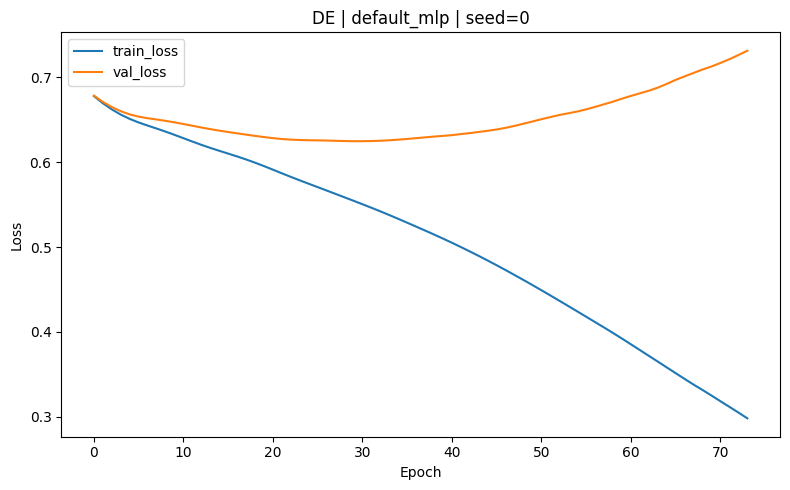

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default MLP on dataset: EN
  Seed 0 ...


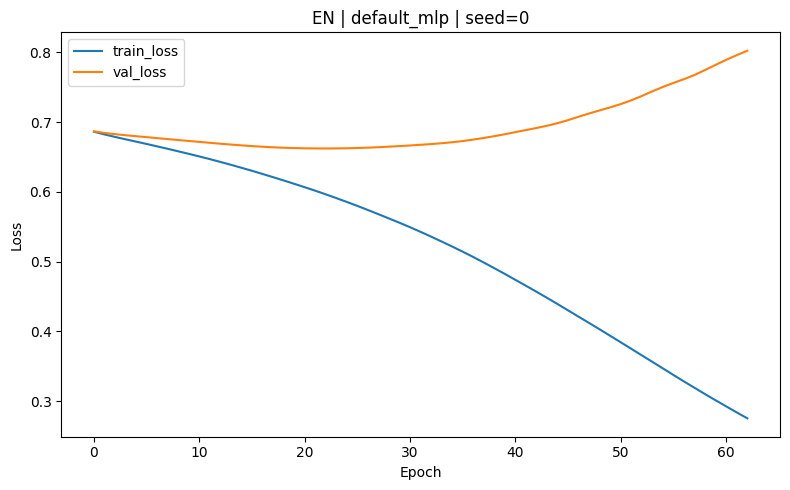

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default MLP on dataset: ES
  Seed 0 ...


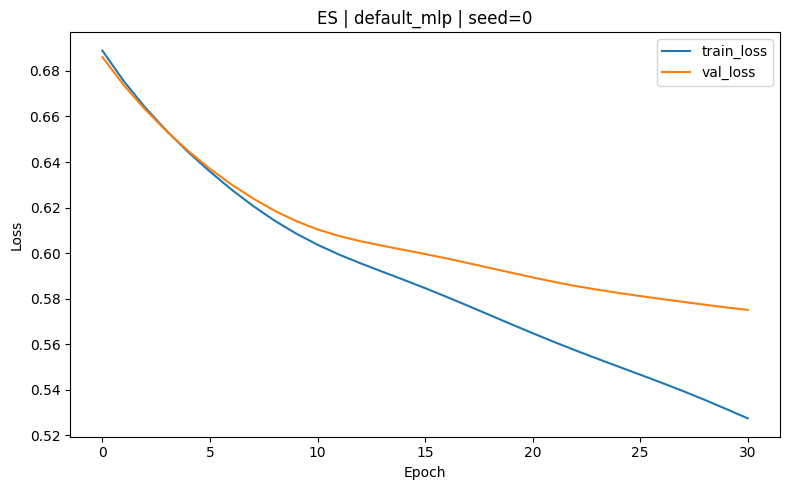

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default MLP on dataset: FR
  Seed 0 ...


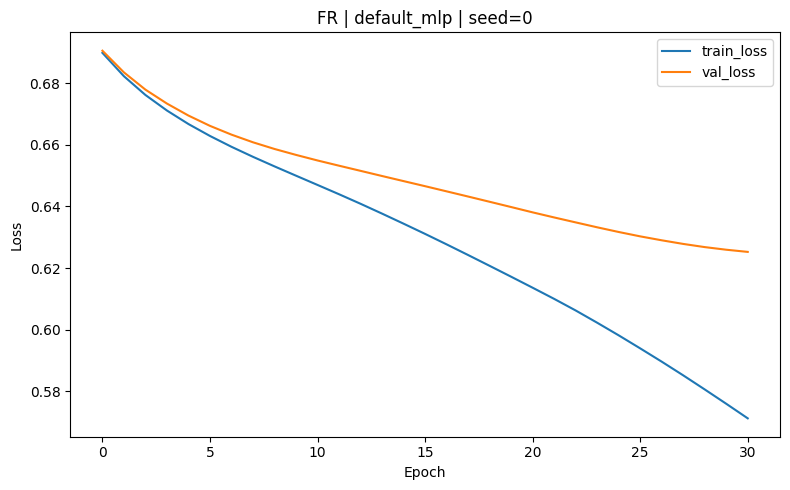

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default MLP on dataset: PT
  Seed 0 ...


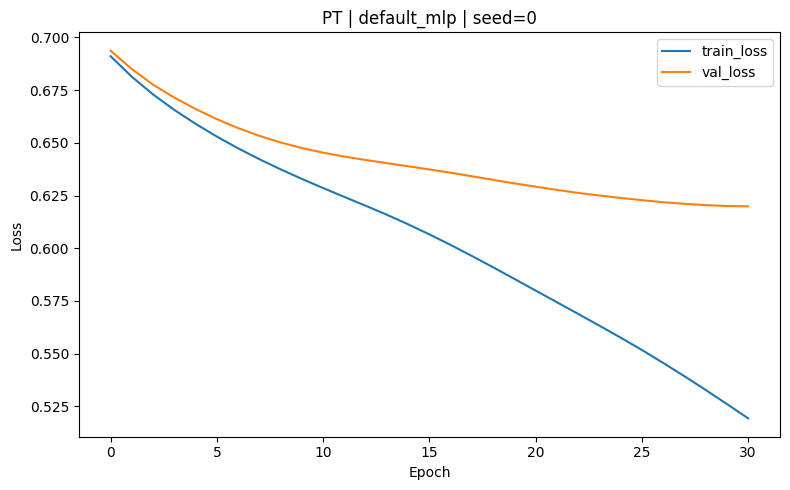

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default MLP on dataset: RU
  Seed 0 ...


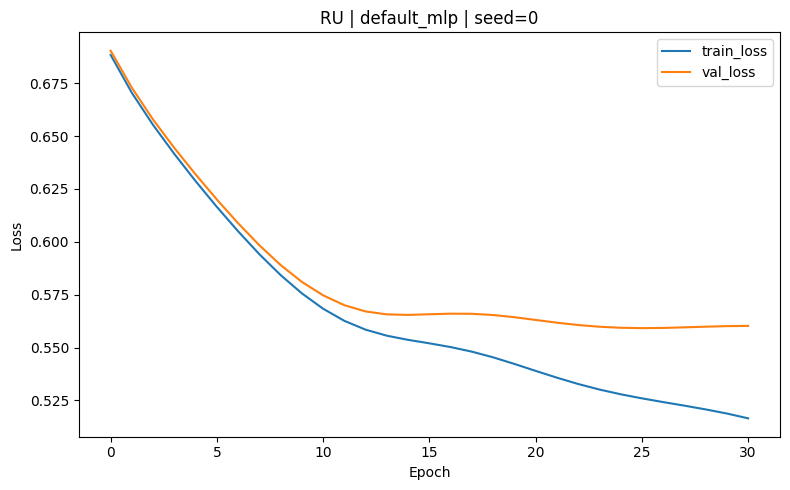

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...


,dataset,seed,run_name,hidden_dims,dropout_rate,learning_rate,weight_decay,max_epochs,patience,best_epoch,...,test_accuracy,train_f1,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc
0,DE,0,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,43,...,0.651579,0.830986,0.727791,0.730016,0.768165,0.615753,0.619459,0.855430,0.675694,0.665497
1,DE,1,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,53,...,0.653158,0.846292,0.726461,0.731349,0.790522,0.610985,0.621057,0.873920,0.665560,0.683020
2,DE,2,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,44,...,0.670526,0.816236,0.738056,0.743653,0.747873,0.637250,0.641340,0.836645,0.692992,0.706802
3,DE,3,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,48,...,0.653158,0.825393,0.725721,0.735235,0.751768,0.610807,0.616283,0.843556,0.672266,0.696418
4,DE,4,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,46,...,0.651053,0.826915,0.742015,0.725010,0.765349,0.639049,0.623844,0.847982,0.690221,0.673637
5,EN,0,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,32,...,0.589060,0.796304,0.671174,0.638718,0.763369,0.616863,0.581147,0.845464,0.636074,0.618835
6,EN,1,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,30,...,0.586255,0.765853,0.655576,0.635802,0.727773,0.599997,0.578453,0.804167,0.643303,0.612319
7,EN,2,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,30,...,0.596774,0.772923,0.635860,0.658348,0.735849,0.577098,0.583237,0.813126,0.611329,0.636872
8,EN,3,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,28,...,0.598177,0.747192,0.662345,0.665889,0.688992,0.582690,0.580966,0.781363,0.611132,0.630729
9,EN,4,default_mlp,"[64, 64]",0.5,0.001,0.0001,200,30,27,...,0.579243,0.760668,0.659731,0.630086,0.723400,0.601247,0.571141,0.797489,0.648733,0.615951


Saved per-run results to: outputs/metrics/mlp_results.csv


In [9]:
# ============================================================
# Cell 8: Main experiment loop (default MLP baseline)
# ============================================================
default_results = []
representative_result = None

for dataset_name in DATASET_NAMES:
    x_np = dataset_data[dataset_name]["x_np"]
    y_np = dataset_data[dataset_name]["y_np"]

    print("=" * 80)
    print(f"Running default MLP on dataset: {dataset_name}")

    for seed in SEEDS:
        print(f"  Seed {seed} ...")
        result = train_one_run(
            x_np=x_np,
            y_np=y_np,
            splits=all_splits[dataset_name][seed],
            seed=seed,
            config=DEFAULT_CONFIG,
            dataset_name=dataset_name,
            run_name="default_mlp",
            save_training_curve=(seed == SEEDS[0])  # only save first seed per dataset
        )

        row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
        default_results.append(row)

        if representative_result is None:
            representative_result = result

default_results_df = pd.DataFrame(default_results).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(default_results_df.head(12))

default_results_path = os.path.join(METRICS_DIR, "mlp_results.csv")
default_results_df.to_csv(default_results_path, index=False)

print(f"Saved per-run results to: {default_results_path}")

## 9 - aggregate results

In [10]:
# ============================================================
# Cell 9: Aggregate default results
# ============================================================
# CHANGED: macro_f1 is now the headline aggregated metric (matches MAIN_METRIC).
agg_df = (
    default_results_df
    .groupby("dataset", as_index=False)
    .agg({
        "test_macro_f1": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"],
        "test_roc_auc": ["mean", "std"],
        "val_macro_f1": ["mean", "std"],
        "elapsed_seconds": ["mean"]
    })
)

agg_df.columns = [
    "dataset",
    "test_macro_f1_mean", "test_macro_f1_std",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std",
    "test_roc_auc_mean", "test_roc_auc_std",
    "val_macro_f1_mean", "val_macro_f1_std",
    "elapsed_seconds_mean"
]

display(agg_df)

agg_path = os.path.join(METRICS_DIR, "mlp_results_aggregated.csv")
agg_df.to_csv(agg_path, index=False)

print(f"Saved aggregated results to: {agg_path}")


,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std,test_roc_auc_mean,test_roc_auc_std,val_macro_f1_mean,val_macro_f1_std,elapsed_seconds_mean
0,DE,0.624397,0.009859,0.733053,0.006963,0.655895,0.008233,0.685075,0.016726,0.622769,0.014194,9.938852
1,EN,0.578989,0.004704,0.645769,0.015476,0.589902,0.007799,0.622941,0.010407,0.595579,0.015908,6.693464
2,ES,0.459094,0.035713,0.139737,0.130293,0.656559,0.059377,0.471925,0.024130,0.468983,0.052711,4.779802
3,FR,0.559832,0.026069,0.406257,0.011561,0.616018,0.045908,0.600781,0.046690,0.569152,0.023658,6.748375
4,PT,0.566450,0.040007,0.390046,0.063636,0.640731,0.045471,0.596161,0.039229,0.571309,0.048749,3.812688
5,RU,0.460626,0.020248,0.119349,0.105339,0.687799,0.090312,0.509363,0.035501,0.459687,0.028929,4.356608


Saved aggregated results to: outputs/metrics/mlp_results_aggregated.csv


## 10 - plot default MLP results

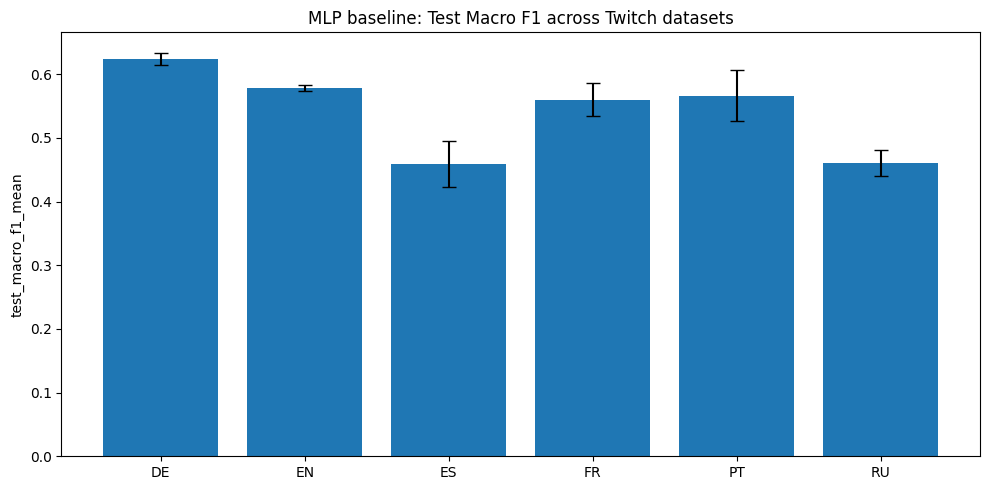

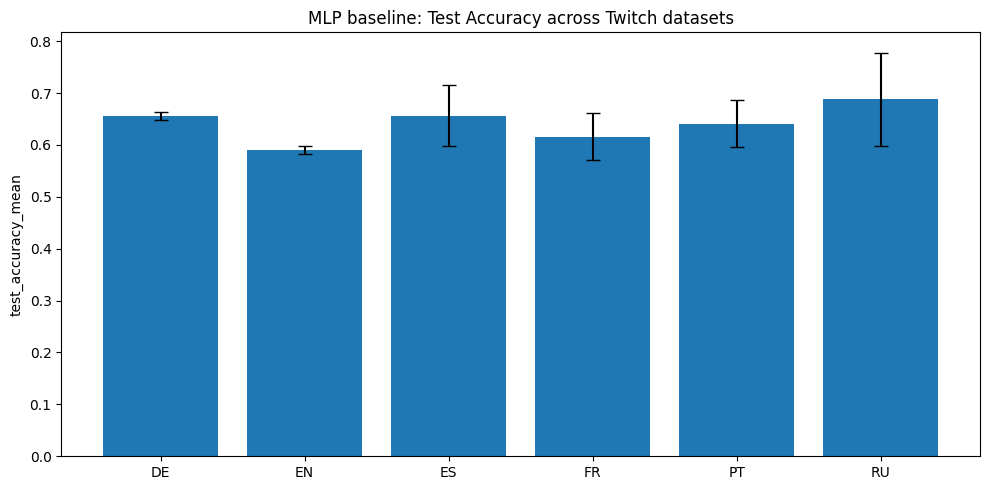

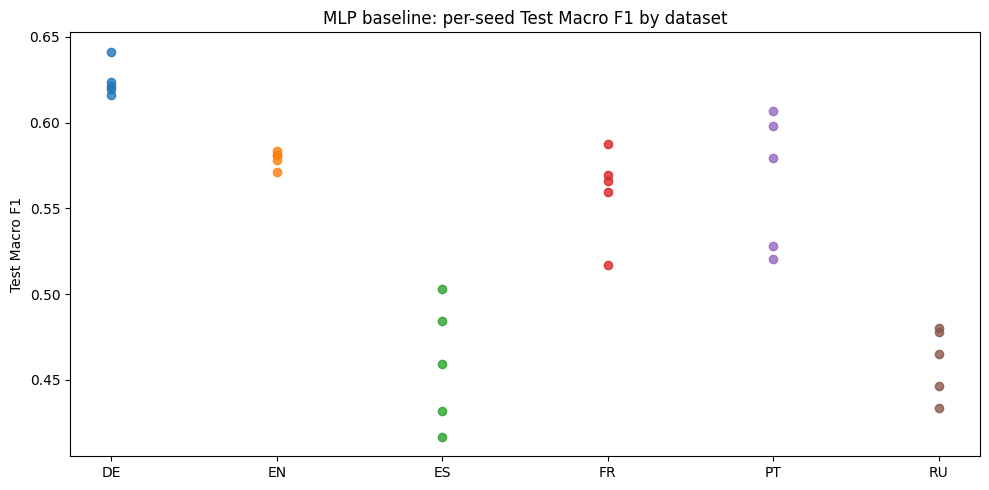

Saved default result plots.


In [11]:
# ============================================================
# Cell 10: Plots for default MLP results
# ============================================================
# CHANGED: headline plot is now Macro F1.
plot_bar_with_error(
    df=agg_df,
    metric_col="test_macro_f1_mean",
    std_col="test_macro_f1_std",
    title="MLP baseline: Test Macro F1 across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "mlp_test_macro_f1_barplot.png")
)

# Plot 2: Test accuracy mean +/- std across datasets (kept for context)
plot_bar_with_error(
    df=agg_df,
    metric_col="test_accuracy_mean",
    std_col="test_accuracy_std",
    title="MLP baseline: Test Accuracy across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "mlp_test_accuracy_barplot.png")
)

# Plot 3: Per-seed Macro F1 scatter by dataset
plt.figure(figsize=(10, 5))
for i, dataset_name in enumerate(DATASET_NAMES):
    vals = default_results_df.loc[default_results_df["dataset"] == dataset_name, "test_macro_f1"].values
    x = np.full_like(vals, fill_value=i, dtype=float)
    plt.scatter(x, vals, alpha=0.8)

plt.xticks(np.arange(len(DATASET_NAMES)), DATASET_NAMES)
plt.ylabel("Test Macro F1")
plt.title("MLP baseline: per-seed Test Macro F1 by dataset")
plt.tight_layout()
scatter_path = os.path.join(FIGURES_DIR, "mlp_test_macro_f1_scatter.png")
plt.savefig(scatter_path, dpi=200)
plt.show()

print("Saved default result plots.")


## 11 - run ablations

In [12]:
# ============================================================
# Cell 11: MLP ablations
# ============================================================
# To keep runtime manageable, do ablations on a subset of seeds by default.
ABLATION_SEEDS = [0, 1, 2]

ablation_results = []

# -----------------------------
# Ablation A: hidden dimension
# -----------------------------
for hidden_dim in ABLATION_GRID["hidden_dim"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["hidden_dims"] = [hidden_dim, hidden_dim]

    for dataset_name in DATASET_NAMES:
        x_np = dataset_data[dataset_name]["x_np"]
        y_np = dataset_data[dataset_name]["y_np"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation hidden_dim={hidden_dim}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                x_np=x_np,
                y_np=y_np,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_hidden{hidden_dim}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
            row["ablation_type"] = "hidden_dim"
            row["ablation_value"] = hidden_dim
            ablation_results.append(row)

# -----------------------------
# Ablation B: number of layers
# -----------------------------
for num_layers in ABLATION_GRID["num_layers"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["hidden_dims"] = prepare_hidden_dims(hidden_dim=64, num_layers=num_layers)

    for dataset_name in DATASET_NAMES:
        x_np = dataset_data[dataset_name]["x_np"]
        y_np = dataset_data[dataset_name]["y_np"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation num_layers={num_layers}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                x_np=x_np,
                y_np=y_np,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_layers{num_layers}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
            row["ablation_type"] = "num_layers"
            row["ablation_value"] = num_layers
            ablation_results.append(row)

# -----------------------------
# Ablation C: dropout rate
# -----------------------------
for dropout_rate in ABLATION_GRID["dropout_rate"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["dropout_rate"] = dropout_rate

    for dataset_name in DATASET_NAMES:
        x_np = dataset_data[dataset_name]["x_np"]
        y_np = dataset_data[dataset_name]["y_np"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation dropout={dropout_rate}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                x_np=x_np,
                y_np=y_np,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_dropout{dropout_rate}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
            row["ablation_type"] = "dropout_rate"
            row["ablation_value"] = dropout_rate
            ablation_results.append(row)

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["ablation_type", "ablation_value", "dataset", "seed"]
).reset_index(drop=True)

display(ablation_results_df.head(20))

ablation_results_path = os.path.join(METRICS_DIR, "mlp_ablation_results.csv")
ablation_results_df.to_csv(ablation_results_path, index=False)
print(f"Saved ablation results to: {ablation_results_path}")

[Ablation hidden_dim=32] dataset=DE, seed=0
[Ablation hidden_dim=32] dataset=DE, seed=1
[Ablation hidden_dim=32] dataset=DE, seed=2
[Ablation hidden_dim=32] dataset=EN, seed=0
[Ablation hidden_dim=32] dataset=EN, seed=1
[Ablation hidden_dim=32] dataset=EN, seed=2
[Ablation hidden_dim=32] dataset=ES, seed=0
[Ablation hidden_dim=32] dataset=ES, seed=1
[Ablation hidden_dim=32] dataset=ES, seed=2
[Ablation hidden_dim=32] dataset=FR, seed=0
[Ablation hidden_dim=32] dataset=FR, seed=1
[Ablation hidden_dim=32] dataset=FR, seed=2
[Ablation hidden_dim=32] dataset=PT, seed=0
[Ablation hidden_dim=32] dataset=PT, seed=1
[Ablation hidden_dim=32] dataset=PT, seed=2
[Ablation hidden_dim=32] dataset=RU, seed=0
[Ablation hidden_dim=32] dataset=RU, seed=1
[Ablation hidden_dim=32] dataset=RU, seed=2
[Ablation hidden_dim=64] dataset=DE, seed=0
[Ablation hidden_dim=64] dataset=DE, seed=1
[Ablation hidden_dim=64] dataset=DE, seed=2
[Ablation hidden_dim=64] dataset=EN, seed=0
[Ablation hidden_dim=64] dataset

,dataset,seed,run_name,hidden_dims,dropout_rate,learning_rate,weight_decay,max_epochs,patience,best_epoch,...,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,ablation_type,ablation_value
0,DE,0,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,28,...,0.724661,0.725932,0.766628,0.616183,0.616829,0.850885,0.673611,0.663219,dropout_rate,0.0
1,DE,1,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,38,...,0.721284,0.725620,0.800583,0.613742,0.622230,0.882881,0.658264,0.671995,dropout_rate,0.0
2,DE,2,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,34,...,0.732429,0.737357,0.778363,0.628102,0.629806,0.866086,0.683218,0.694510,dropout_rate,0.0
3,EN,0,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,19,...,0.668311,0.635468,0.755704,0.615100,0.576692,0.843348,0.635067,0.616988,dropout_rate,0.0
4,EN,1,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,19,...,0.656039,0.627836,0.730747,0.597913,0.565351,0.818606,0.638152,0.610008,dropout_rate,0.0
5,EN,2,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,28,...,0.617517,0.629969,0.816606,0.568458,0.566423,0.898404,0.596735,0.610609,dropout_rate,0.0
6,ES,0,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,0,...,0.350626,0.334471,0.529616,0.535805,0.514174,0.543024,0.566869,0.502028,dropout_rate,0.0
7,ES,1,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,40,...,0.358140,0.321782,0.817878,0.582566,0.566798,0.931103,0.632565,0.626157,dropout_rate,0.0
8,ES,2,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,36,...,0.346604,0.348485,0.759076,0.575954,0.586128,0.898284,0.620913,0.650165,dropout_rate,0.0
9,FR,0,ablation_dropout0.0,"[64, 64]",0.0,0.001,0.0001,200,30,31,...,0.442432,0.388815,0.757971,0.604540,0.571746,0.876317,0.643489,0.625269,dropout_rate,0.0


Saved ablation results to: outputs/metrics/mlp_ablation_results.csv


## 12 - summarize and plot results

,ablation_type,ablation_value,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std
0,dropout_rate,0.0,DE,0.622955,0.006519,0.729636,0.006688,0.653158,0.006963
1,dropout_rate,0.0,EN,0.569488,0.006261,0.631091,0.003938,0.578308,0.005711
2,dropout_rate,0.0,ES,0.555700,0.037238,0.334913,0.013357,0.669534,0.077459
3,dropout_rate,0.0,FR,0.570491,0.005411,0.400385,0.012989,0.638444,0.019161
4,dropout_rate,0.0,PT,0.570137,0.059575,0.377059,0.092312,0.657093,0.043871
5,dropout_rate,0.0,RU,0.463417,0.030183,0.138376,0.140495,0.672748,0.098333
6,dropout_rate,0.2,DE,0.624913,0.006444,0.731900,0.005932,0.655439,0.006581
7,dropout_rate,0.2,EN,0.573471,0.008640,0.634124,0.005364,0.582281,0.005964
8,dropout_rate,0.2,ES,0.511976,0.051274,0.261456,0.110299,0.645878,0.062313
9,dropout_rate,0.2,FR,0.571512,0.014386,0.404577,0.011749,0.636664,0.018844


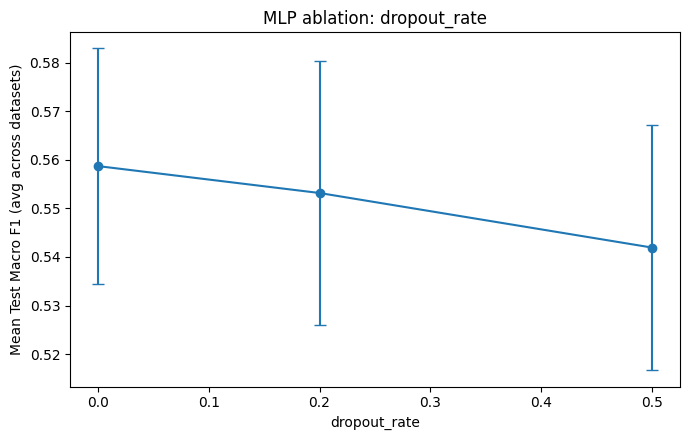

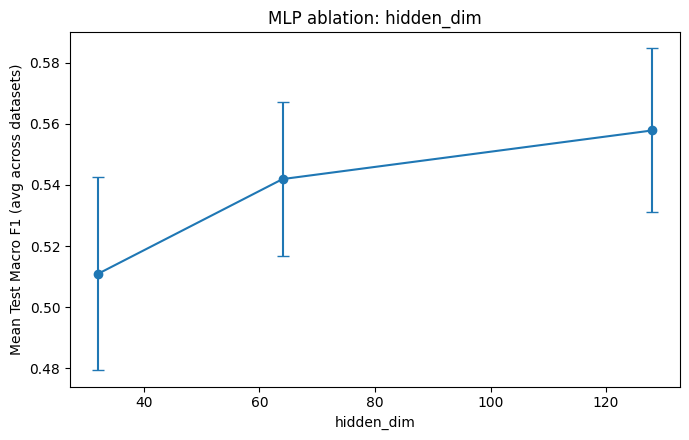

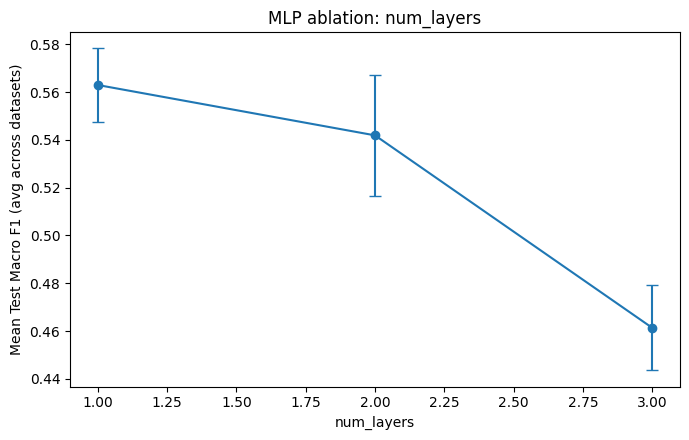

Saved ablation summary to: outputs/metrics/mlp_ablation_summary.csv


In [13]:
# ============================================================
# Cell 12: Summarize and plot ablation results
# ============================================================
# CHANGED: ablation plot uses Macro F1 (matches headline metric).
ablation_summary_df = (
    ablation_results_df
    .groupby(["ablation_type", "ablation_value", "dataset"], as_index=False)
    .agg({
        "test_macro_f1": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"]
    })
)

ablation_summary_df.columns = [
    "ablation_type", "ablation_value", "dataset",
    "test_macro_f1_mean", "test_macro_f1_std",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std"
]

display(ablation_summary_df.head(20))

ablation_summary_path = os.path.join(METRICS_DIR, "mlp_ablation_summary.csv")
ablation_summary_df.to_csv(ablation_summary_path, index=False)

# One plot per ablation type: average across datasets, on Macro F1.
for ablation_type in ablation_summary_df["ablation_type"].unique():
    sub = ablation_summary_df[ablation_summary_df["ablation_type"] == ablation_type].copy()

    collapsed = (
        sub.groupby("ablation_value", as_index=False)
        .agg({
            "test_macro_f1_mean": "mean",
            "test_macro_f1_std": "mean"
        })
        .sort_values("ablation_value")
    )

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        collapsed["ablation_value"].values,
        collapsed["test_macro_f1_mean"].values,
        yerr=collapsed["test_macro_f1_std"].values,
        marker="o",
        capsize=4
    )
    plt.xlabel(ablation_type)
    plt.ylabel("Mean Test Macro F1 (avg across datasets)")
    plt.title(f"MLP ablation: {ablation_type}")
    plt.tight_layout()

    fig_path = os.path.join(FIGURES_DIR, f"mlp_ablation_{ablation_type}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

print(f"Saved ablation summary to: {ablation_summary_path}")


## 13 - final summary

In [14]:
# ============================================================
# Cell 13: Final summary table
# ============================================================
# CHANGED: best run per dataset is now picked by val_macro_f1 (then test_macro_f1
# as a tiebreaker), matching the new headline metric.
best_default_runs_df = (
    default_results_df
    .sort_values(["dataset", "val_macro_f1", "test_macro_f1"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

final_summary_df = best_default_runs_df[[
    "dataset",
    "seed",
    "hidden_dims",
    "dropout_rate",
    "learning_rate",
    "weight_decay",
    "best_epoch",
    "val_macro_f1",
    "test_accuracy",
    "test_f1",
    "test_macro_f1",
    "test_roc_auc"
]].copy()

display(final_summary_df)

final_summary_path = os.path.join(METRICS_DIR, "mlp_final_summary.csv")
final_summary_df.to_csv(final_summary_path, index=False)

print(f"Saved final summary to: {final_summary_path}")
print("Notebook finished successfully.")


,dataset,seed,hidden_dims,dropout_rate,learning_rate,weight_decay,best_epoch,val_macro_f1,test_accuracy,test_f1,test_macro_f1,test_roc_auc
0,DE,4,"[64, 64]",0.5,0.001,0.0001,46,0.639049,0.651053,0.725010,0.623844,0.673637
1,EN,0,"[64, 64]",0.5,0.001,0.0001,32,0.616863,0.589060,0.638718,0.581147,0.618835
2,ES,0,"[64, 64]",0.5,0.001,0.0001,0,0.540768,0.561290,0.333333,0.503205,0.503291
3,FR,3,"[64, 64]",0.5,0.001,0.0001,54,0.591597,0.637681,0.397972,0.569417,0.632594
4,PT,2,"[64, 64]",0.5,0.001,0.0001,39,0.617845,0.639687,0.281250,0.520416,0.572226
5,RU,2,"[64, 64]",0.5,0.001,0.0001,0,0.497944,0.698974,0.142857,0.480142,0.519019


Saved final summary to: outputs/metrics/mlp_final_summary.csv
Notebook finished successfully.


## 14 - Additional Evaluations

Running extra evaluations for dataset: DE
  Seed 0 ...
  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running extra evaluations for dataset: EN
  Seed 0 ...
  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running extra evaluations for dataset: ES
  Seed 0 ...
  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running extra evaluations for dataset: FR
  Seed 0 ...
  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running extra evaluations for dataset: PT
  Seed 0 ...
  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running extra evaluations for dataset: RU
  Seed 0 ...
  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...


,dataset,seed,n_train,n_val,n_test,train_pos_frac,val_pos_frac,test_pos_frac,model,threshold_source,...,balanced_accuracy,pr_auc,tn,fp,fn,tp,pred_pos_rate,true_pos_rate,val_best_f1_for_threshold_selection,majority_class
0,DE,0,5698,1900,1900,0.604598,0.604737,0.604211,mlp_default_threshold,fixed_0.50,...,0.617867,0.734349,343,409,253,895,0.686316,0.604211,NaN,NaN
1,DE,0,5698,1900,1900,0.604598,0.604737,0.604211,mlp_tuned_threshold,best_val_f1,...,0.507590,0.734349,16,736,7,1141,0.987895,0.604211,0.754941,NaN
2,DE,0,5698,1900,1900,0.604598,0.604737,0.604211,majority_class_baseline,none,...,0.500000,0.604211,0,752,0,1148,1.000000,NaN,NaN,1.0
3,DE,0,5698,1900,1900,0.604598,0.604737,0.604211,logistic_regression_default_threshold,fixed_0.50,...,0.609661,0.722760,349,403,281,867,0.668421,0.604211,NaN,NaN
4,DE,0,5698,1900,1900,0.604598,0.604737,0.604211,logistic_regression_tuned_threshold,best_val_f1,...,0.513094,0.722760,40,712,31,1117,0.962632,0.604211,0.758943,NaN
5,DE,1,5698,1900,1900,0.604598,0.604211,0.604737,mlp_default_threshold,fixed_0.50,...,0.619367,0.745350,344,407,252,897,0.686316,0.604737,NaN,NaN
6,DE,1,5698,1900,1900,0.604598,0.604211,0.604737,mlp_tuned_threshold,best_val_f1,...,0.533554,0.745350,87,664,56,1093,0.924737,0.604737,0.759780,NaN
7,DE,1,5698,1900,1900,0.604598,0.604211,0.604737,majority_class_baseline,none,...,0.500000,0.604737,0,751,0,1149,1.000000,NaN,NaN,1.0
8,DE,1,5698,1900,1900,0.604598,0.604211,0.604737,logistic_regression_default_threshold,fixed_0.50,...,0.610073,0.732025,332,419,255,894,0.691053,0.604737,NaN,NaN
9,DE,1,5698,1900,1900,0.604598,0.604211,0.604737,logistic_regression_tuned_threshold,best_val_f1,...,0.525356,0.732025,59,692,32,1117,0.952105,0.604737,0.756940,NaN


,dataset,model,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,balanced_accuracy_mean,balanced_accuracy_std,pr_auc_mean,pr_auc_std,selected_threshold_mean,selected_threshold_std,tn_sum,fp_sum,fn_sum,tp_sum
0,DE,logistic_regression_default_threshold,0.646526,0.004918,0.723525,0.005940,0.686053,0.005387,0.765544,0.015843,0.615145,0.005804,0.735637,0.011739,0.50,0.000000,1747,2012,1346,4395
1,DE,logistic_regression_tuned_threshold,0.616316,0.008196,0.753947,0.002178,0.615659,0.007133,0.972653,0.013629,0.522374,0.013545,0.735637,0.011739,0.18,0.057009,271,3488,157,5584
2,DE,majority_class_baseline,0.604316,0.000235,0.753363,0.000183,0.604316,0.000235,1.000000,0.000000,0.500000,0.000000,0.604316,0.000235,NaN,NaN,0,3759,0,5741
3,DE,mlp_default_threshold,0.655895,0.008233,0.733053,0.006963,0.690053,0.007375,0.781920,0.013610,0.622670,0.009354,0.751144,0.014954,0.50,0.000000,1742,2017,1252,4489
4,DE,mlp_tuned_threshold,0.625158,0.010973,0.754886,0.003013,0.624487,0.011741,0.955235,0.029658,0.538138,0.020942,0.751144,0.014954,0.33,0.057009,455,3304,257,5484
5,EN,logistic_regression_default_threshold,0.566059,0.010371,0.608011,0.009500,0.599576,0.011060,0.616967,0.016511,0.560952,0.011171,0.624533,0.005102,0.50,0.000000,1636,1604,1490,2400
6,EN,logistic_regression_tuned_threshold,0.548387,0.004704,0.705886,0.001713,0.547485,0.002825,0.993316,0.005918,0.503757,0.005561,0.624533,0.005102,0.07,0.027386,46,3194,26,3864
7,EN,majority_class_baseline,0.545582,0.000000,0.705989,0.000000,0.545582,0.000000,1.000000,0.000000,0.500000,0.000000,0.545582,0.000000,NaN,NaN,0,3240,0,3890
8,EN,mlp_default_threshold,0.589902,0.007799,0.645769,0.015476,0.610476,0.003213,0.686118,0.034697,0.580250,0.005571,0.654919,0.008685,0.50,0.000000,1537,1703,1221,2669
9,EN,mlp_tuned_threshold,0.552454,0.009068,0.703081,0.004226,0.551254,0.007541,0.971722,0.038162,0.510398,0.013739,0.654919,0.008685,0.21,0.151658,159,3081,110,3780


Saved: outputs/extra_evals/metrics/comparison_f1_mean.csv
Saved: outputs/extra_evals/metrics/comparison_accuracy_mean.csv
Saved: outputs/extra_evals/metrics/comparison_precision_mean.csv
Saved: outputs/extra_evals/metrics/comparison_recall_mean.csv
Saved: outputs/extra_evals/metrics/comparison_balanced_accuracy_mean.csv
Saved: outputs/extra_evals/metrics/comparison_pr_auc_mean.csv


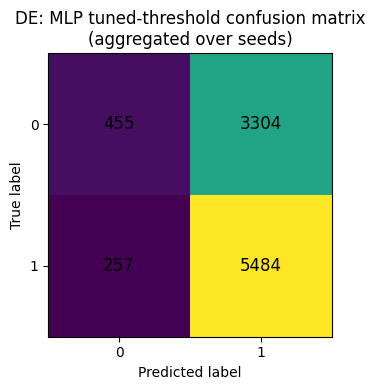

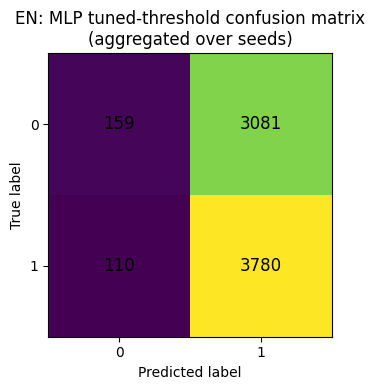

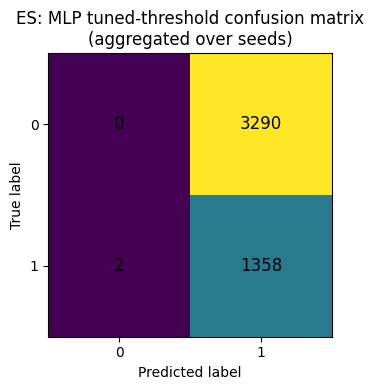

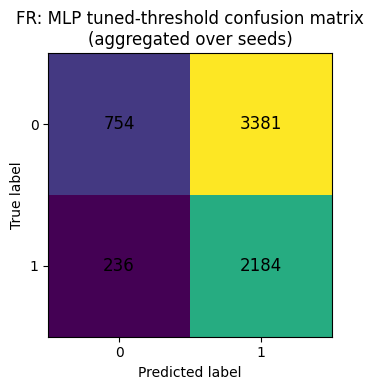

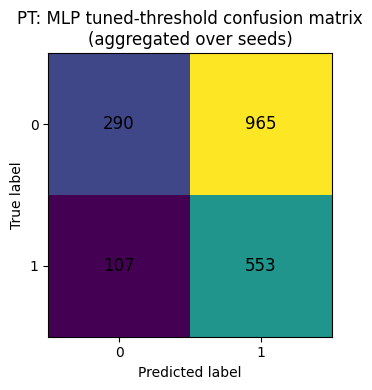

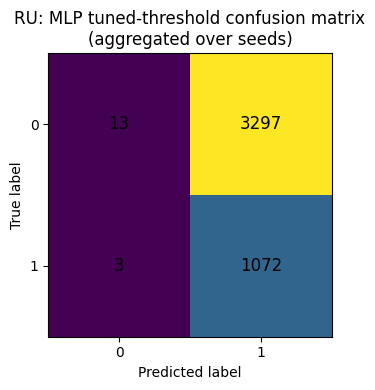

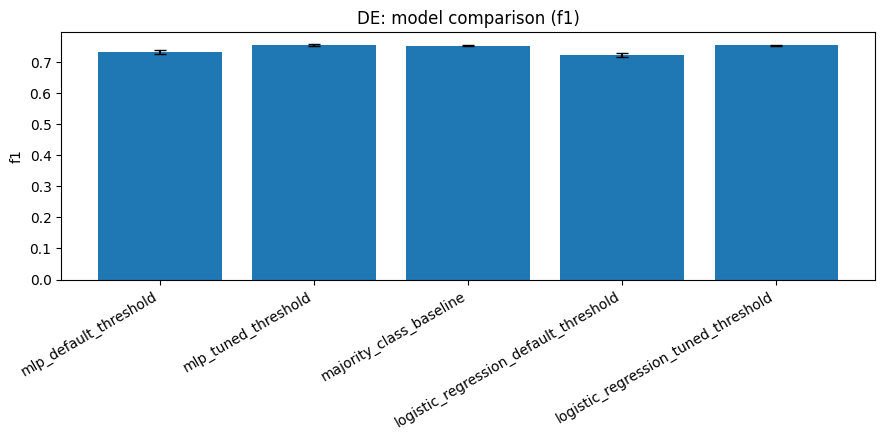

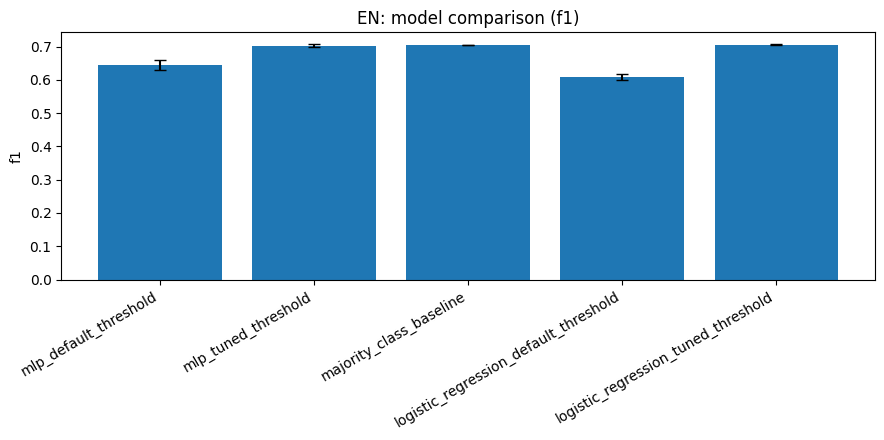

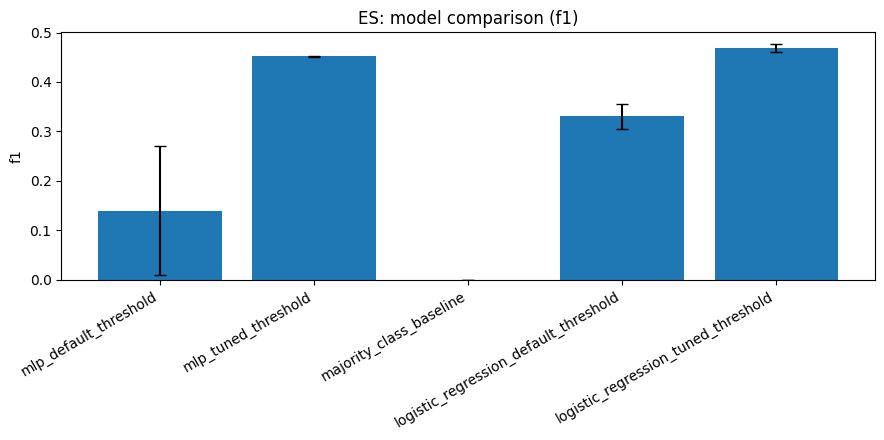

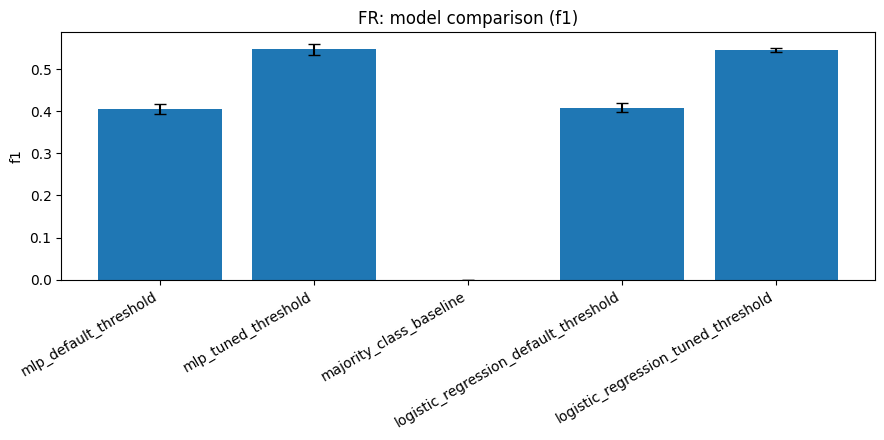

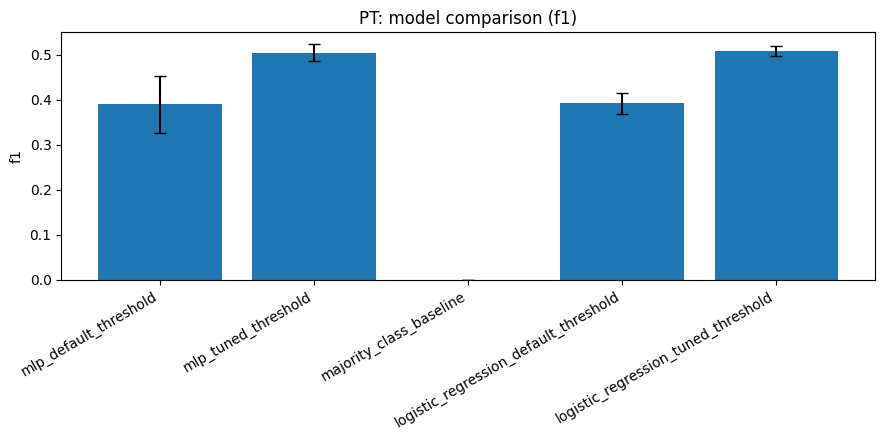

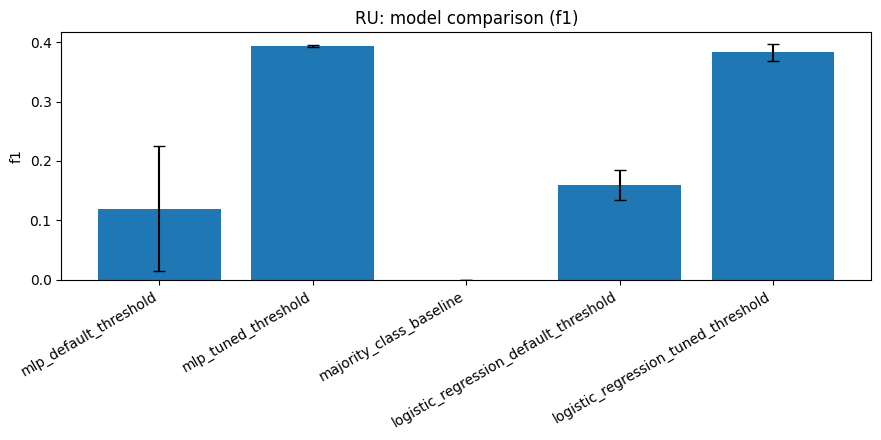

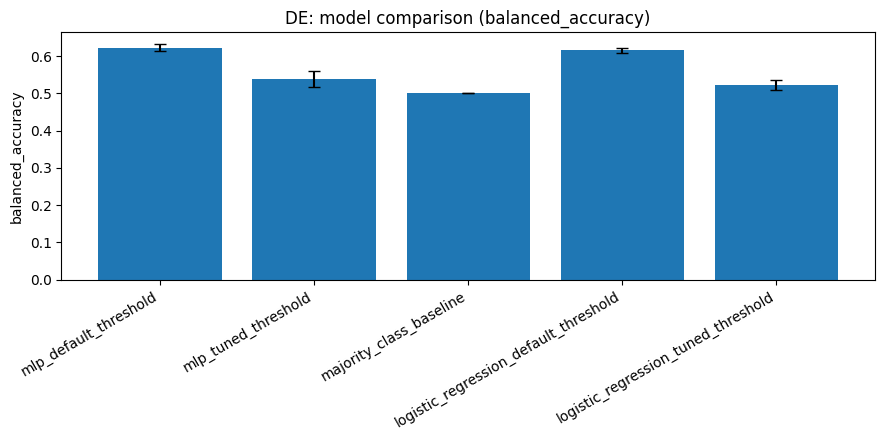

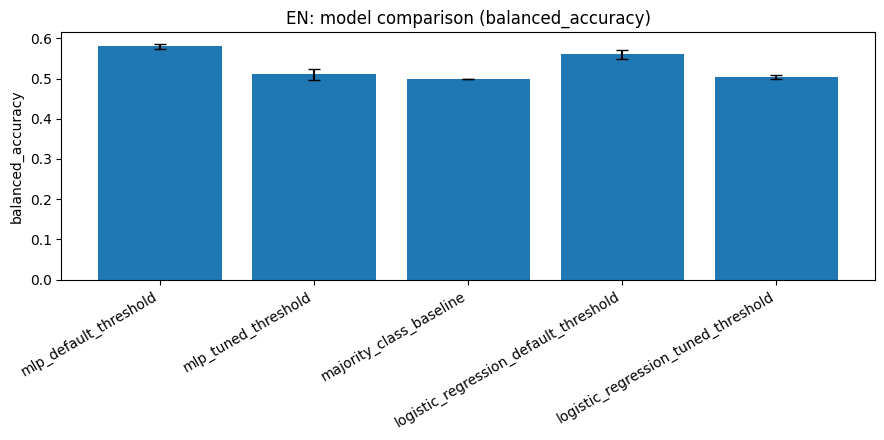

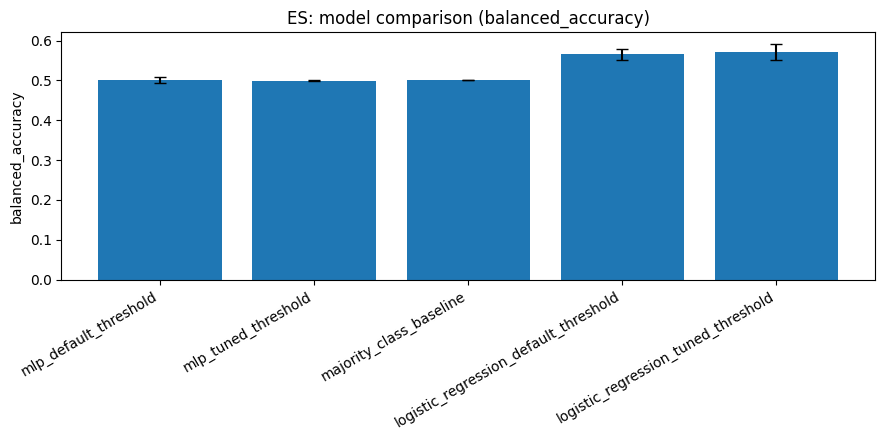

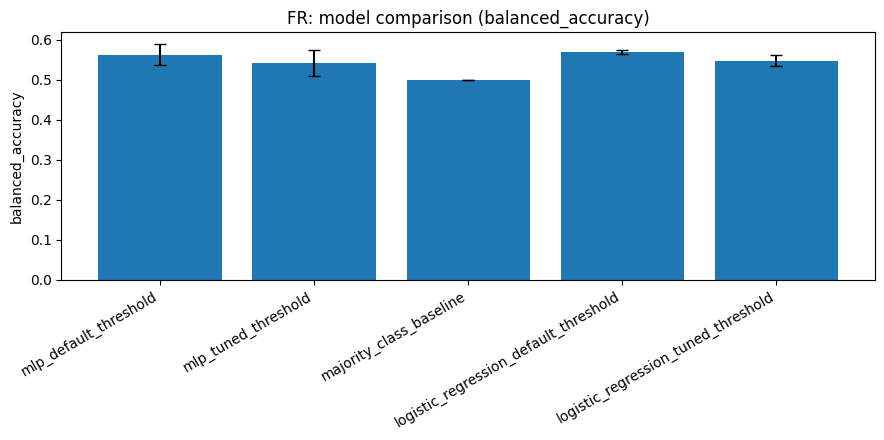

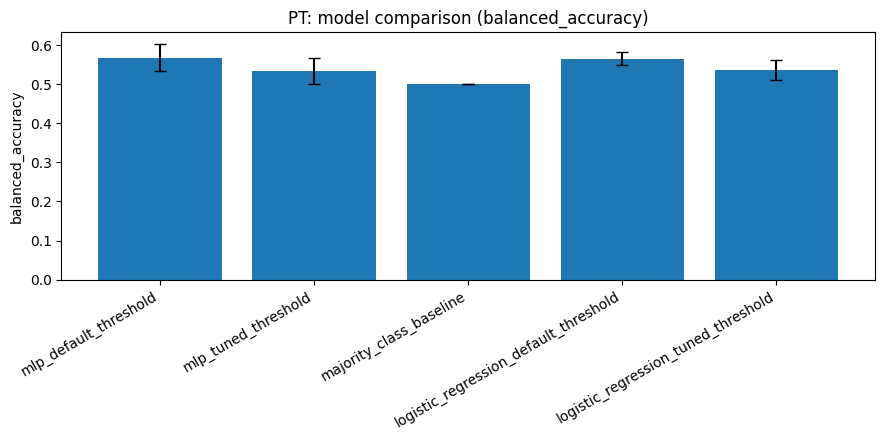

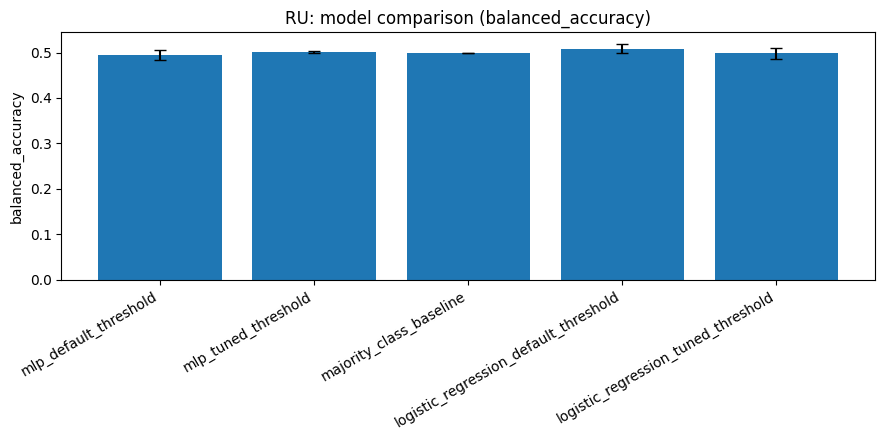

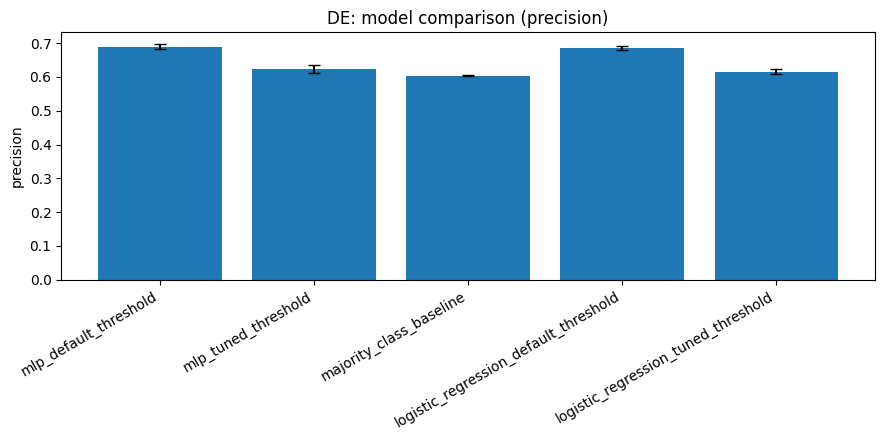

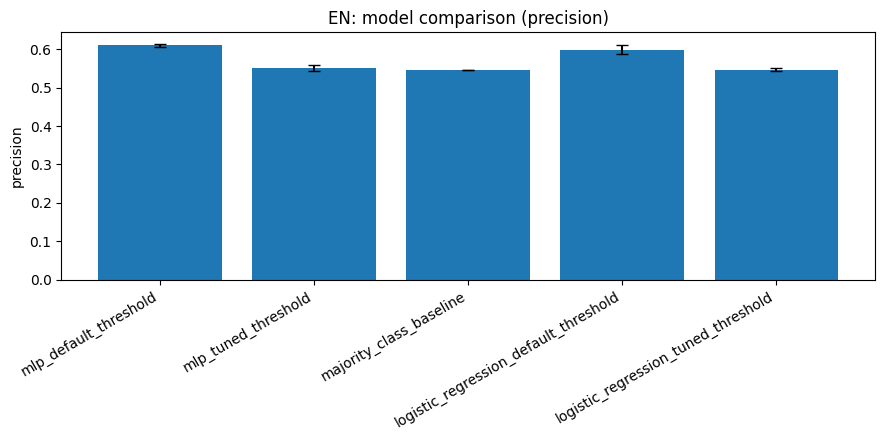

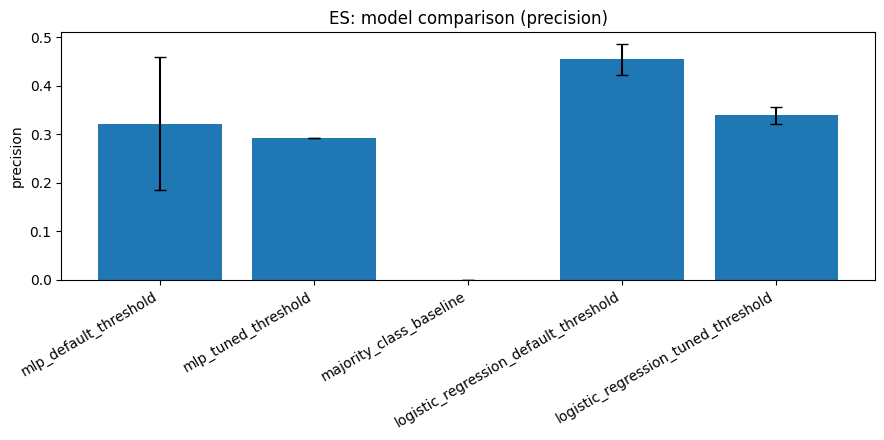

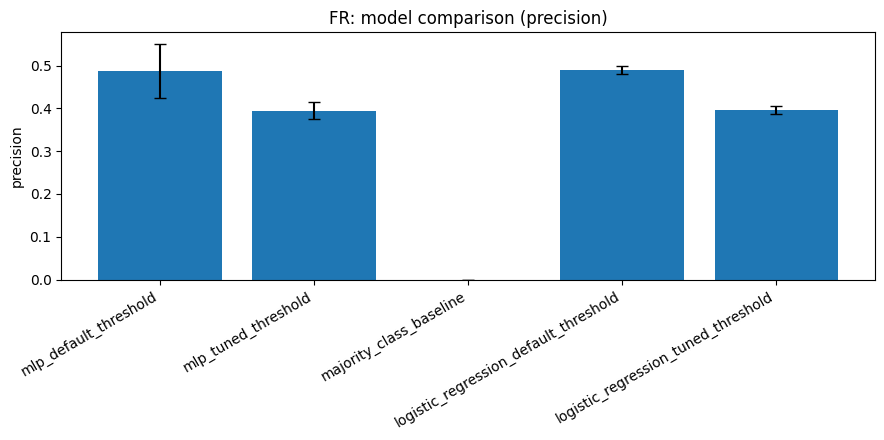

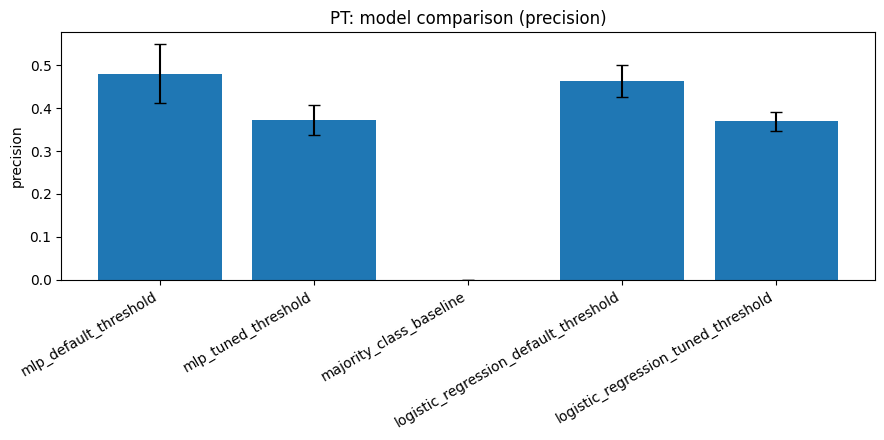

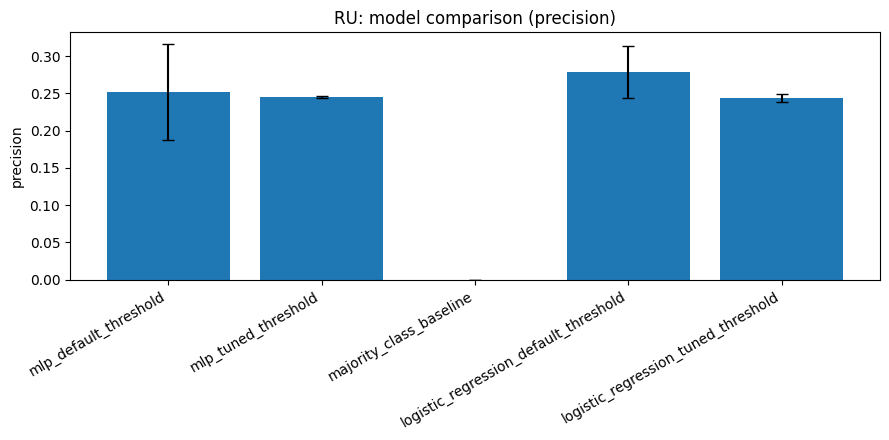

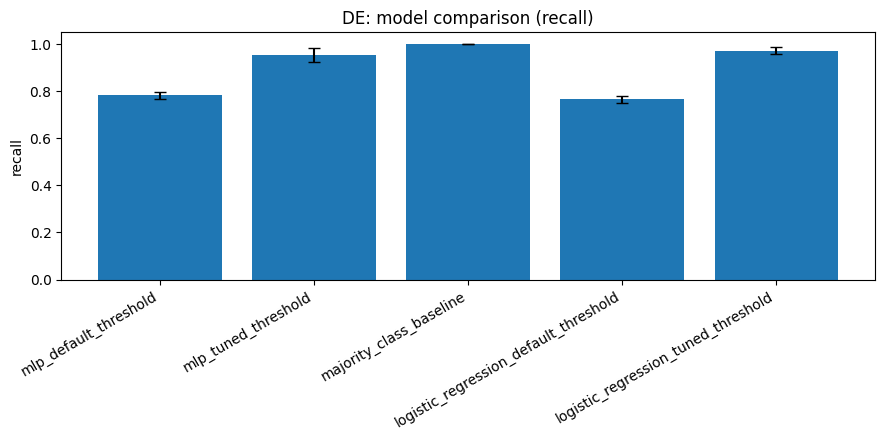

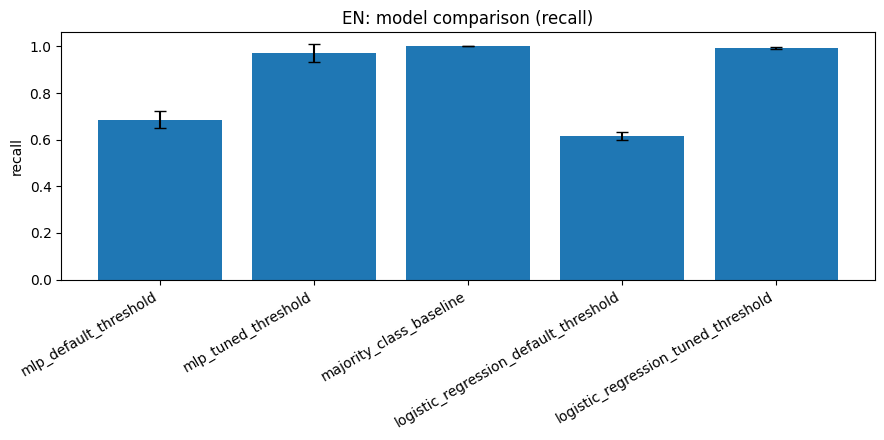

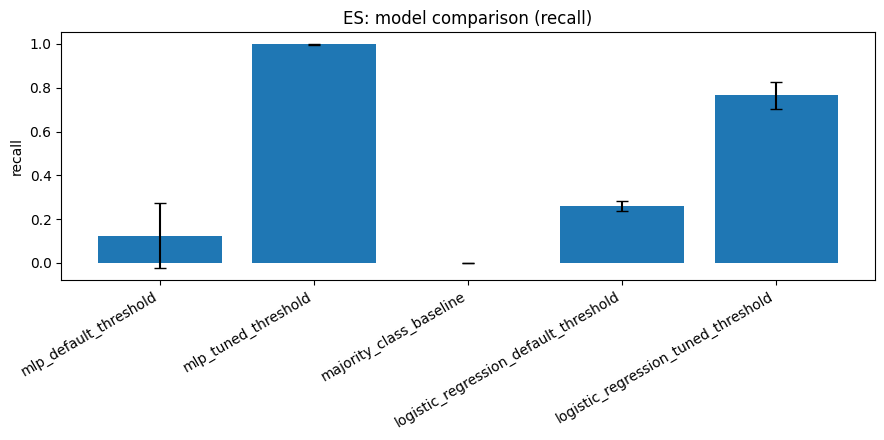

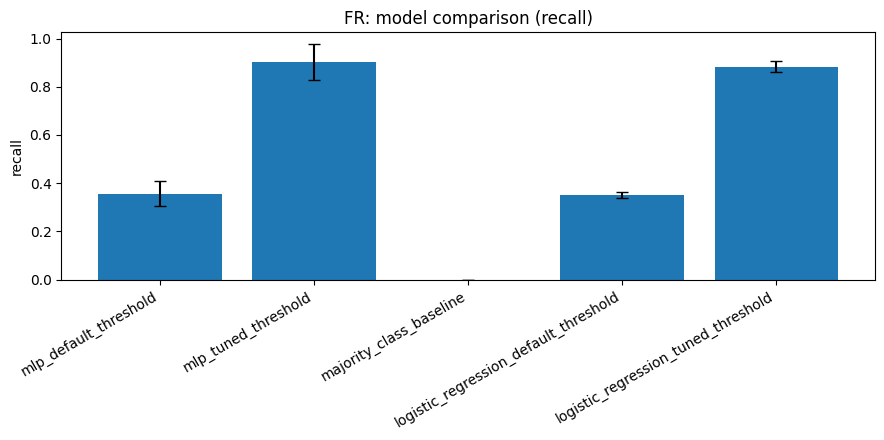

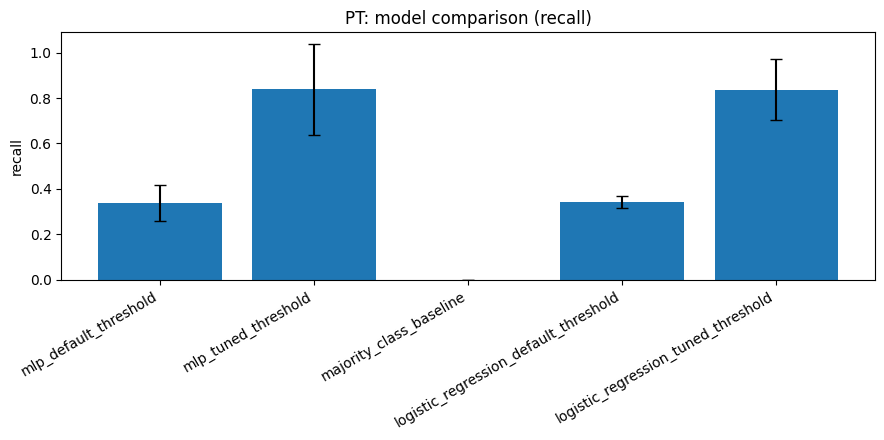

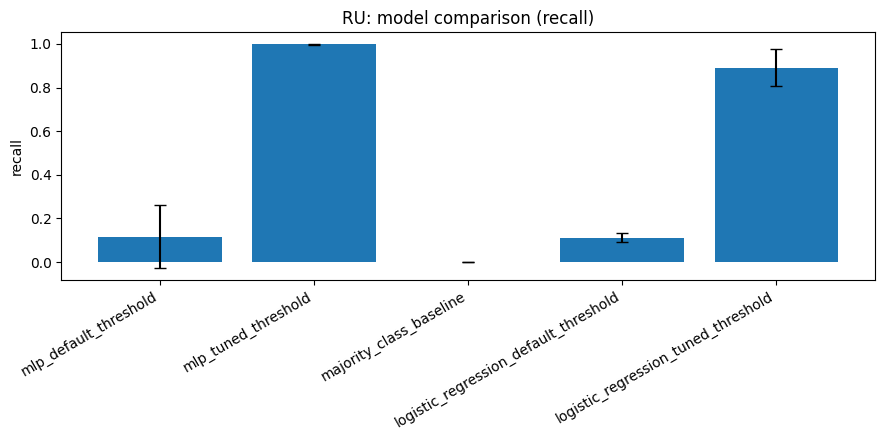

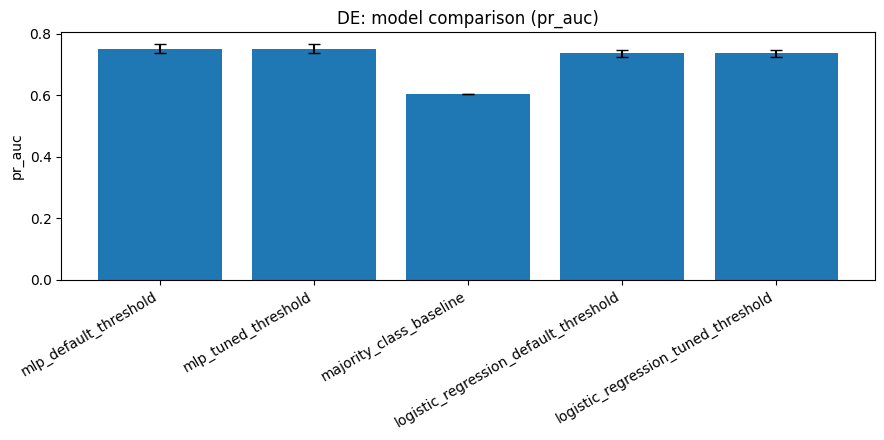

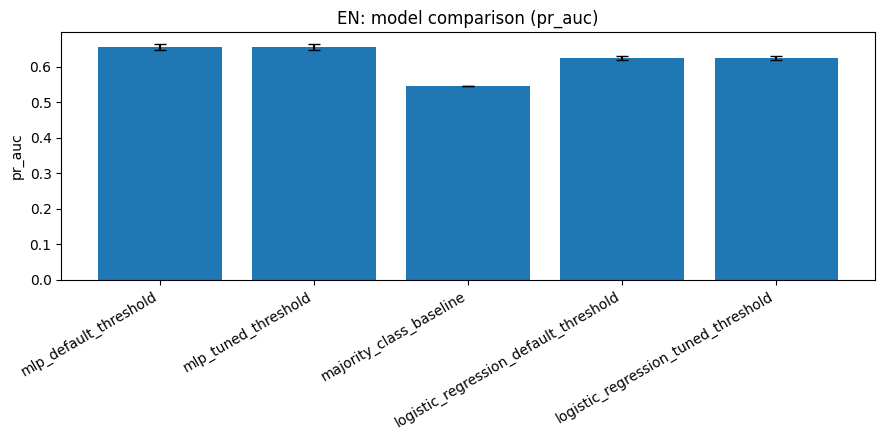

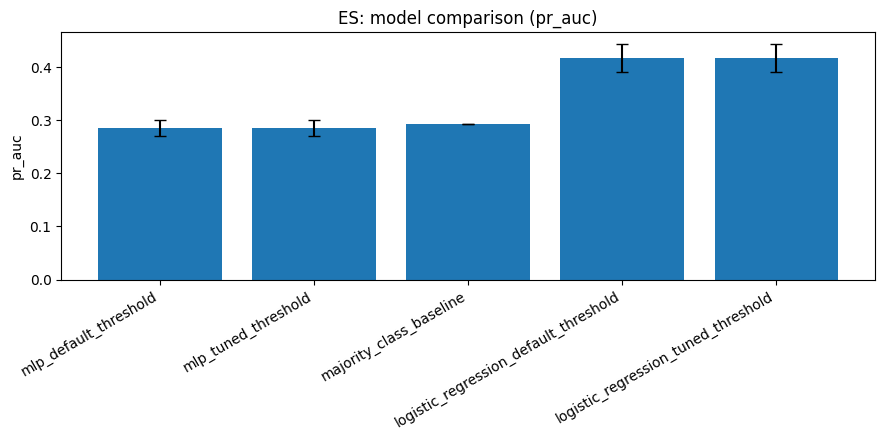

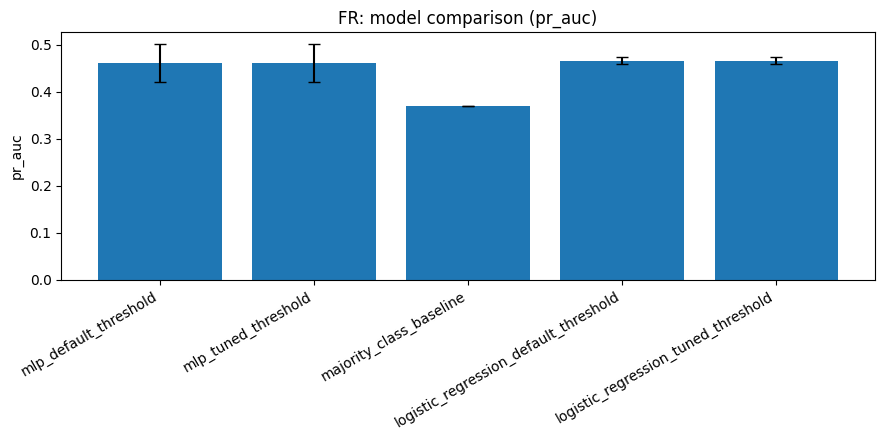

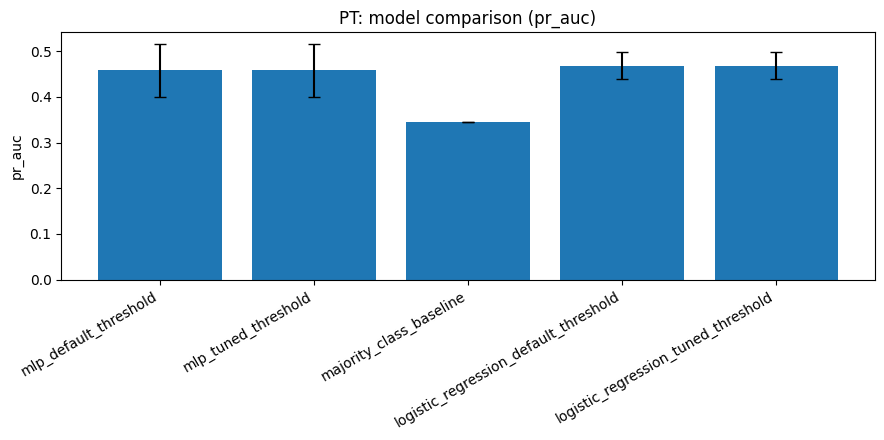

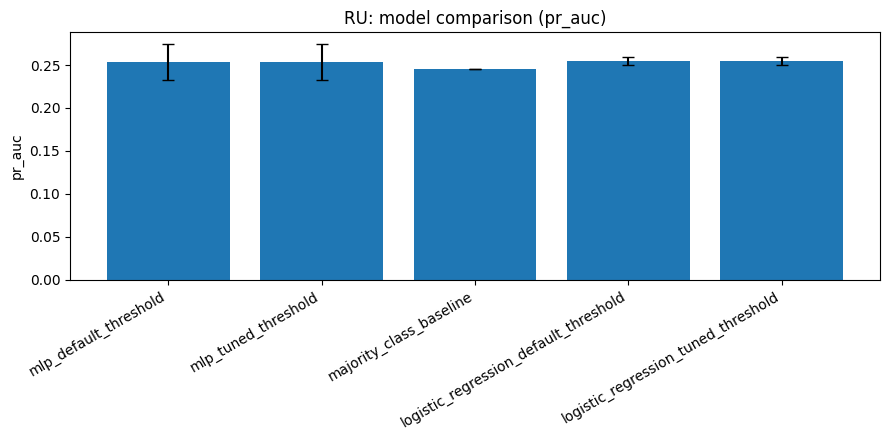


Saved detailed results to: outputs/extra_evals/metrics/extra_eval_detailed_results.csv
Saved summary results to: outputs/extra_evals/metrics/extra_eval_summary_results.csv
Saved confusion matrices and comparison plots in: outputs/extra_evals/figures


In [15]:
# ============================================================
# Extra evaluation cell:
# 1) Confusion matrices
# 2) Precision / Recall / Balanced Accuracy / PR-AUC
# 3) Majority-class baseline
# 4) Logistic regression baseline
# 5) Threshold tuning on validation set (for MLP)
#
# This cell re-runs the default MLP once per dataset/seed so we can
# recover probabilities and best parameters, then computes all five
# evaluations and saves the results.
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    average_precision_score,
    accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression

EXTRA_EVAL_DIR = os.path.join(ROOT_OUTPUT_DIR, "extra_evals")
EXTRA_FIG_DIR = os.path.join(EXTRA_EVAL_DIR, "figures")
EXTRA_CSV_DIR = os.path.join(EXTRA_EVAL_DIR, "metrics")
os.makedirs(EXTRA_EVAL_DIR, exist_ok=True)
os.makedirs(EXTRA_FIG_DIR, exist_ok=True)
os.makedirs(EXTRA_CSV_DIR, exist_ok=True)

THRESHOLD_GRID = np.linspace(0.05, 0.95, 19)

def sigmoid_or_softmax_positive_prob(logits: np.ndarray) -> np.ndarray:
    # For 2-class logits, use softmax probability of class 1
    probs = softmax_numpy(logits)
    return probs[:, 1]

def metrics_from_probs_binary(y_true: np.ndarray, pos_probs: np.ndarray, threshold: float) -> Dict[str, float]:
    y_pred = (pos_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    out = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, average="binary", zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, average="binary", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="binary", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "pr_auc": float(average_precision_score(y_true, pos_probs)) if len(np.unique(y_true)) == 2 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "pred_pos_rate": float(y_pred.mean()),
        "true_pos_rate": float(y_true.mean()),
    }
    return out

def choose_best_threshold_by_val_f1(y_val: np.ndarray, val_pos_probs: np.ndarray, threshold_grid: np.ndarray):
    best_threshold = 0.50
    best_metrics = None
    best_f1 = -1.0

    for thr in threshold_grid:
        m = metrics_from_probs_binary(y_val, val_pos_probs, threshold=thr)
        if m["f1"] > best_f1:
            best_f1 = m["f1"]
            best_threshold = float(thr)
            best_metrics = m

    return best_threshold, best_metrics

def evaluate_majority_baseline(y_train: np.ndarray, y_eval: np.ndarray) -> Dict[str, float]:
    majority_class = int(np.mean(y_train) >= 0.5)
    y_pred = np.full_like(y_eval, fill_value=majority_class)
    # use hard probabilities compatible with metrics requiring probs
    pos_probs = np.full(len(y_eval), float(majority_class), dtype=np.float64)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()

    return {
        "majority_class": majority_class,
        "accuracy": float(accuracy_score(y_eval, y_pred)),
        "f1": float(f1_score(y_eval, y_pred, average="binary", zero_division=0)),
        "precision": float(precision_score(y_eval, y_pred, average="binary", zero_division=0)),
        "recall": float(recall_score(y_eval, y_pred, average="binary", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_eval, y_pred)),
        "pr_auc": float(average_precision_score(y_eval, pos_probs)) if len(np.unique(y_eval)) == 2 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "pred_pos_rate": float(y_pred.mean()),
    }

def evaluate_logreg_baseline(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    seed: int
) -> Dict[str, Dict[str, float]]:
    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=1000,
        random_state=seed
    )
    clf.fit(x_train, y_train)

    val_pos_probs = clf.predict_proba(x_val)[:, 1]
    test_pos_probs = clf.predict_proba(x_test)[:, 1]

    # default threshold 0.5
    test_default = metrics_from_probs_binary(y_test, test_pos_probs, threshold=0.50)

    # tuned threshold from validation
    best_thr, val_best = choose_best_threshold_by_val_f1(y_val, val_pos_probs, THRESHOLD_GRID)
    test_tuned = metrics_from_probs_binary(y_test, test_pos_probs, threshold=best_thr)

    return {
        "default": test_default,
        "tuned": test_tuned,
        "best_threshold": float(best_thr),
        "val_best_f1": float(val_best["f1"]),
    }

def build_default_mlp_model_for_x(x_np: np.ndarray, y_np: np.ndarray):
    return MLP(
        input_dim=x_np.shape[1],
        hidden_dims=DEFAULT_CONFIG["hidden_dims"],
        output_dim=len(np.unique(y_np)),
        dropout_rate=DEFAULT_CONFIG["dropout_rate"],
        use_batch_norm=DEFAULT_CONFIG.get("use_batch_norm", False)
    )

# ------------------------------------------------------------
# Main evaluation loop
# ------------------------------------------------------------
extra_eval_rows = []

# aggregate confusion matrices for tuned MLP, summed over seeds
agg_confusion_by_dataset = {
    name: {"tn": 0, "fp": 0, "fn": 0, "tp": 0} for name in DATASET_NAMES
}

for dataset_name in DATASET_NAMES:
    x_np = dataset_data[dataset_name]["x_np"]
    y_np = dataset_data[dataset_name]["y_np"]

    print("=" * 90)
    print(f"Running extra evaluations for dataset: {dataset_name}")

    for seed in SEEDS:
        print(f"  Seed {seed} ...")

        splits = all_splits[dataset_name][seed]
        train_idx = splits["train"]
        val_idx = splits["val"]
        test_idx = splits["test"]

        x_train, y_train = x_np[train_idx], y_np[train_idx]
        x_val, y_val = x_np[val_idx], y_np[val_idx]
        x_test, y_test = x_np[test_idx], y_np[test_idx]

        # -----------------------------
        # Re-train default MLP once to recover best params
        # -----------------------------
        mlp_result = train_one_run(
            x_np=x_np,
            y_np=y_np,
            splits=splits,
            seed=seed,
            config=DEFAULT_CONFIG,
            dataset_name=dataset_name,
            run_name="default_mlp_extra_eval",
            save_training_curve=False
        )

        best_params = mlp_result["best_params"]
        mlp_model = build_default_mlp_model_for_x(x_np, y_np)
        x_jnp = jnp.asarray(x_np, dtype=JAX_DTYPE)

        logits_all = np.asarray(mlp_model(best_params, x_jnp, rng_key=None, train=False))
        val_pos_probs = sigmoid_or_softmax_positive_prob(logits_all[val_idx])
        test_pos_probs = sigmoid_or_softmax_positive_prob(logits_all[test_idx])

        # 1 + 2: confusion matrix + precision/recall/balanced acc/PR-AUC
        mlp_test_default = metrics_from_probs_binary(y_test, test_pos_probs, threshold=0.50)

        # 5: threshold tuning using validation set
        best_thr_mlp, mlp_val_best = choose_best_threshold_by_val_f1(y_val, val_pos_probs, THRESHOLD_GRID)
        mlp_test_tuned = metrics_from_probs_binary(y_test, test_pos_probs, threshold=best_thr_mlp)

        # 3: majority-class baseline
        majority_test = evaluate_majority_baseline(y_train, y_test)

        # 4: logistic regression baseline
        logreg_out = evaluate_logreg_baseline(
            x_train=x_train,
            y_train=y_train,
            x_val=x_val,
            y_val=y_val,
            x_test=x_test,
            y_test=y_test,
            seed=seed
        )
        logreg_test_default = logreg_out["default"]
        logreg_test_tuned = logreg_out["tuned"]

        # Save per-run rows
        row_common = {
            "dataset": dataset_name,
            "seed": seed,
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "train_pos_frac": float(y_train.mean()),
            "val_pos_frac": float(y_val.mean()),
            "test_pos_frac": float(y_test.mean()),
        }

        extra_eval_rows.append({
            **row_common,
            "model": "mlp_default_threshold",
            "threshold_source": "fixed_0.50",
            "selected_threshold": 0.50,
            **mlp_test_default
        })

        extra_eval_rows.append({
            **row_common,
            "model": "mlp_tuned_threshold",
            "threshold_source": "best_val_f1",
            "selected_threshold": float(best_thr_mlp),
            "val_best_f1_for_threshold_selection": float(mlp_val_best["f1"]),
            **mlp_test_tuned
        })

        extra_eval_rows.append({
            **row_common,
            "model": "majority_class_baseline",
            "threshold_source": "none",
            "selected_threshold": np.nan,
            **majority_test
        })

        extra_eval_rows.append({
            **row_common,
            "model": "logistic_regression_default_threshold",
            "threshold_source": "fixed_0.50",
            "selected_threshold": 0.50,
            **logreg_test_default
        })

        extra_eval_rows.append({
            **row_common,
            "model": "logistic_regression_tuned_threshold",
            "threshold_source": "best_val_f1",
            "selected_threshold": float(logreg_out["best_threshold"]),
            "val_best_f1_for_threshold_selection": float(logreg_out["val_best_f1"]),
            **logreg_test_tuned
        })

        # aggregate tuned MLP confusion counts across seeds
        agg_confusion_by_dataset[dataset_name]["tn"] += mlp_test_tuned["tn"]
        agg_confusion_by_dataset[dataset_name]["fp"] += mlp_test_tuned["fp"]
        agg_confusion_by_dataset[dataset_name]["fn"] += mlp_test_tuned["fn"]
        agg_confusion_by_dataset[dataset_name]["tp"] += mlp_test_tuned["tp"]

# ------------------------------------------------------------
# Save detailed metrics
# ------------------------------------------------------------
extra_eval_df = pd.DataFrame(extra_eval_rows)
display(extra_eval_df.head(20))

extra_eval_path = os.path.join(EXTRA_CSV_DIR, "extra_eval_detailed_results.csv")
extra_eval_df.to_csv(extra_eval_path, index=False)

# ------------------------------------------------------------
# Save aggregated summary
# ------------------------------------------------------------
extra_eval_summary_df = (
    extra_eval_df
    .groupby(["dataset", "model"], as_index=False)
    .agg({
        "accuracy": ["mean", "std"],
        "f1": ["mean", "std"],
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "pr_auc": ["mean", "std"],
        "selected_threshold": ["mean", "std"],
        "tn": "sum",
        "fp": "sum",
        "fn": "sum",
        "tp": "sum",
    })
)

extra_eval_summary_df.columns = [
    "dataset", "model",
    "accuracy_mean", "accuracy_std",
    "f1_mean", "f1_std",
    "precision_mean", "precision_std",
    "recall_mean", "recall_std",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "pr_auc_mean", "pr_auc_std",
    "selected_threshold_mean", "selected_threshold_std",
    "tn_sum", "fp_sum", "fn_sum", "tp_sum"
]

display(extra_eval_summary_df)

extra_eval_summary_path = os.path.join(EXTRA_CSV_DIR, "extra_eval_summary_results.csv")
extra_eval_summary_df.to_csv(extra_eval_summary_path, index=False)

# ------------------------------------------------------------
# Save compact comparison tables for easy reporting
# ------------------------------------------------------------
comparison_tables = {}
for metric_name in ["f1_mean", "accuracy_mean", "precision_mean", "recall_mean", "balanced_accuracy_mean", "pr_auc_mean"]:
    table = extra_eval_summary_df.pivot(index="dataset", columns="model", values=metric_name)
    comparison_tables[metric_name] = table
    table_path = os.path.join(EXTRA_CSV_DIR, f"comparison_{metric_name}.csv")
    table.to_csv(table_path)
    print(f"Saved: {table_path}")

# ------------------------------------------------------------
# Plot confusion matrices for tuned MLP aggregated across seeds
# ------------------------------------------------------------
for dataset_name in DATASET_NAMES:
    cm = agg_confusion_by_dataset[dataset_name]
    cm_arr = np.array([[cm["tn"], cm["fp"]],
                       [cm["fn"], cm["tp"]]], dtype=np.int64)

    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm_arr)
    plt.title(f"{dataset_name}: MLP tuned-threshold confusion matrix\n(aggregated over seeds)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm_arr[i, j]), ha="center", va="center", fontsize=12)

    plt.tight_layout()
    fig_path = os.path.join(EXTRA_FIG_DIR, f"{dataset_name}_mlp_tuned_confusion_matrix.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

# ------------------------------------------------------------
# Plot model comparison for F1 and balanced accuracy
# ------------------------------------------------------------
for metric_base in ["f1", "balanced_accuracy", "precision", "recall", "pr_auc"]:
    metric_mean = f"{metric_base}_mean"
    metric_std = f"{metric_base}_std"

    plot_df = extra_eval_summary_df.copy()
    models_order = [
        "mlp_default_threshold",
        "mlp_tuned_threshold",
        "majority_class_baseline",
        "logistic_regression_default_threshold",
        "logistic_regression_tuned_threshold"
    ]

    for dataset_name in DATASET_NAMES:
        sub = plot_df[plot_df["dataset"] == dataset_name].copy()
        sub["model"] = pd.Categorical(sub["model"], categories=models_order, ordered=True)
        sub = sub.sort_values("model")

        plt.figure(figsize=(9, 4.5))
        x = np.arange(len(sub))
        plt.bar(x, sub[metric_mean].values, yerr=sub[metric_std].values, capsize=4)
        plt.xticks(x, sub["model"].values, rotation=30, ha="right")
        plt.ylabel(metric_base)
        plt.title(f"{dataset_name}: model comparison ({metric_base})")
        plt.tight_layout()

        fig_path = os.path.join(EXTRA_FIG_DIR, f"{dataset_name}_comparison_{metric_base}.png")
        plt.savefig(fig_path, dpi=200)
        plt.show()

print("\nSaved detailed results to:", extra_eval_path)
print("Saved summary results to:", extra_eval_summary_path)
print("Saved confusion matrices and comparison plots in:", EXTRA_FIG_DIR)

In [16]:
# ============================================================
# Zip everything inside outputs/extra_evals into one zip file
# ============================================================
import os
import zipfile
from datetime import datetime

ROOT_TO_ZIP = os.path.join("outputs", "extra_evals")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"extra_evals_outputs_{timestamp}.zip"

if not os.path.exists(ROOT_TO_ZIP):
    raise FileNotFoundError(f"Could not find folder: {ROOT_TO_ZIP}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for foldername, _, filenames in os.walk(ROOT_TO_ZIP):
        for filename in filenames:
            full_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(full_path, start=".")
            zf.write(full_path, arcname=arcname)

print(f"Created zip file: {zip_path}")
print(f"Absolute path: {os.path.abspath(zip_path)}")

# Show contents
with zipfile.ZipFile(zip_path, "r") as zf:
    print("\nZip contents:")
    for name in zf.namelist():
        print(" -", name)

Created zip file: extra_evals_outputs_20260505_214819.zip
Absolute path: /content/extra_evals_outputs_20260505_214819.zip

Zip contents:
 - outputs/extra_evals/metrics/extra_eval_summary_results.csv
 - outputs/extra_evals/metrics/comparison_pr_auc_mean.csv
 - outputs/extra_evals/metrics/comparison_balanced_accuracy_mean.csv
 - outputs/extra_evals/metrics/extra_eval_detailed_results.csv
 - outputs/extra_evals/metrics/comparison_recall_mean.csv
 - outputs/extra_evals/metrics/comparison_accuracy_mean.csv
 - outputs/extra_evals/metrics/comparison_precision_mean.csv
 - outputs/extra_evals/metrics/comparison_f1_mean.csv
 - outputs/extra_evals/figures/PT_comparison_balanced_accuracy.png
 - outputs/extra_evals/figures/ES_comparison_f1.png
 - outputs/extra_evals/figures/PT_comparison_precision.png
 - outputs/extra_evals/figures/RU_comparison_recall.png
 - outputs/extra_evals/figures/PT_comparison_pr_auc.png
 - outputs/extra_evals/figures/ES_mlp_tuned_confusion_matrix.png
 - outputs/extra_evals/

In [17]:
# ============================================================
# Final extra cell: bundle all notebook outputs into one zip
# ============================================================
import os
import zipfile
from datetime import datetime

ROOT_TO_ZIP = "outputs"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"mlp_notebook_outputs_{timestamp}.zip"

if not os.path.exists(ROOT_TO_ZIP):
    raise FileNotFoundError(f"Could not find output directory: {ROOT_TO_ZIP}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for foldername, _, filenames in os.walk(ROOT_TO_ZIP):
        for filename in filenames:
            full_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(full_path, start=".")
            zf.write(full_path, arcname=arcname)

print(f"Created zip file: {zip_path}")
print(f"Absolute path: {os.path.abspath(zip_path)}")

# Optional: show contents
with zipfile.ZipFile(zip_path, "r") as zf:
    print("\nZip contents:")
    for name in zf.namelist():
        print(" -", name)

Created zip file: mlp_notebook_outputs_20260505_214819.zip
Absolute path: /content/mlp_notebook_outputs_20260505_214819.zip

Zip contents:
 - outputs/metrics/mlp_split_summary.csv
 - outputs/metrics/mlp_final_summary.csv
 - outputs/metrics/mlp_dataset_summary.csv
 - outputs/metrics/mlp_ablation_summary.csv
 - outputs/metrics/mlp_ablation_results.csv
 - outputs/metrics/mlp_results.csv
 - outputs/metrics/mlp_results_aggregated.csv
 - outputs/figures/mlp_test_macro_f1_barplot.png
 - outputs/figures/PT_default_mlp_seed0_training_curve.png
 - outputs/figures/ES_default_mlp_seed0_training_curve.png
 - outputs/figures/mlp_test_macro_f1_scatter.png
 - outputs/figures/mlp_ablation_dropout_rate.png
 - outputs/figures/mlp_test_accuracy_barplot.png
 - outputs/figures/RU_default_mlp_seed0_training_curve.png
 - outputs/figures/mlp_ablation_num_layers.png
 - outputs/figures/DE_default_mlp_seed0_training_curve.png
 - outputs/figures/EN_default_mlp_seed0_training_curve.png
 - outputs/figures/mlp_ablati